# Breast Tumor AI — Complete End-to-End Explainable Pipeline
### Stage 1 Detection → Segmentation (malignant only) → Stage 3 Classification

**Pipeline flow:**
```
All patients → Stage 1 (Tumor Detection)
                    ↓
     ┌──────────────┴──────────────┐
  Normal/Benign              Malignant
     │                           │
     │                   Segmentation (MONAI+DynUNet+2D)
     │                   Tumor metrics + visualisation
     │                           │
     └───────────┬───────────────┘
              Stage 3 (Benign vs Malignant)
                    ↓
              Final Report
```
**Two modes:** Specific patient (Cell 9) | Random patient (Cell 10) | Batch results (Cell 11+)


In [1]:
import os, sys, json, random, math, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.amp import autocast
from torch.utils.data import DataLoader

# ── Project root ──────────────────────────────────────────────────
PROJECT_ROOT = r"D:\Breast_Tumor_AI_Project"

sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "classification", "stage1"))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "classification", "stage3"))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "classification"))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "segmentation"))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "segmentation_3d"))

# ── Model checkpoints ─────────────────────────────────────────────
STAGE1_CKPT    = os.path.join(PROJECT_ROOT, "models", "classification_stage1", "best_model_raw.pth")
STAGE3_CKPT    = os.path.join(PROJECT_ROOT, "models", "classification_stage3", "best_model.pth")
SEG_MONAI_CKPT = os.path.join(PROJECT_ROOT, "models", "segmentation_3d",       "unet3d_best.pth")
SEG_DYN_CKPT   = os.path.join(PROJECT_ROOT, "models", "dynunet_3d",            "dynunet_best.pth")
SEG_2D_CKPT    = os.path.join(PROJECT_ROOT, "models", "segmentation", "smooth_0.8157", "unet_best.pth")

# fallbacks
for attr, alt in [("STAGE1_CKPT","best_model.pth"),("STAGE3_CKPT","best_model.pth")]:
    if not os.path.isfile(eval(attr)):
        p2 = os.path.join(os.path.dirname(eval(attr)), alt)
        if os.path.isfile(p2): exec(f"{attr}='{p2}'")

# ── Data paths ────────────────────────────────────────────────────
STAGE1_DATA = os.path.join(PROJECT_ROOT, "data", "classification_stage1")
STAGE3_DATA = os.path.join(PROJECT_ROOT, "data", "classification_stage3")
SEG_DATA    = os.path.join(PROJECT_ROOT, "data", "patients_combined")

# ── Training logs ─────────────────────────────────────────────────
STAGE1_LOG = os.path.join(PROJECT_ROOT, "models", "classification_stage1", "training_log.json")
STAGE3_LOG = os.path.join(PROJECT_ROOT, "models", "classification_stage3", "training_log.json")

# ── Pipeline config ───────────────────────────────────────────────
THRESHOLD1   = 0.5      # Stage 1: tumor present
THRESHOLD3   = 0.5      # Stage 3: malignant
VOXEL_MM3    = 1.5**3   # 1.5mm isotropic → 3.375 mm³/voxel
CROP_SIZE_3D = 64       # Stage 3 patch

# ── Style constants ───────────────────────────────────────────────
BG      = "#0d1117"
CARD    = "#161b22"
BORDER  = "#30363d"
TEXT    = "#c9d1d9"
MUTED   = "#8b949e"
BLUE    = "#3b82f6"
GREEN   = "#10b981"
AMBER   = "#f59e0b"
RED     = "#ef4444"
PURPLE  = "#8b5cf6"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

print("\nCheckpoints:")
for name, path in [("Stage 1", STAGE1_CKPT), ("Stage 3", STAGE3_CKPT),
                    ("Seg MONAI", SEG_MONAI_CKPT), ("Seg DynUNet", SEG_DYN_CKPT)]:
    print(f"  {'✓' if os.path.isfile(path) else '✗ MISSING':12s} {name:14s} {os.path.basename(path)}")


Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU

Checkpoints:
  ✓            Stage 1        best_model_raw.pth
  ✓            Stage 3        best_model.pth
  ✓            Seg MONAI      unet3d_best.pth
  ✓            Seg DynUNet    dynunet_best.pth


## 1. Load All Models

In [2]:
# Stage 1
try:
    from dataset_stage1 import FIXED_SIZE
    from model_stage1   import build_model as build_stage1
    model_s1 = build_stage1().to(device).eval()
    ck1   = torch.load(STAGE1_CKPT, map_location=device, weights_only=False)
    st1   = ck1.get("model_state", ck1) if isinstance(ck1, dict) else ck1
    model_s1.load_state_dict(st1)
    print(f"  Stage 1  loaded — epoch={ck1.get('epoch','?')}  val_auc={ck1.get('best_score','?')}")
    STAGE1_OK = True
except Exception as e:
    print(f"  Stage 1  FAILED: {e}"); model_s1=None; STAGE1_OK=False; FIXED_SIZE=(128,192,192)

# Stage 3
try:
    from data_stage3  import Stage3Dataset, STAGE3_ROOT, CROP_SIZE
    from model_stage3 import get_model_stage3
    model_s3 = get_model_stage3(device).eval()
    ck3  = torch.load(STAGE3_CKPT, map_location=device, weights_only=False)
    st3  = ck3.get("model_state", ck3) if isinstance(ck3, dict) else ck3
    model_s3.load_state_dict(st3)
    print(f"  Stage 3  loaded — epoch={ck3.get('epoch','?')}  val_auc={ck3.get('best_score','?')}")
    STAGE3_OK = True
except Exception as e:
    print(f"  Stage 3  FAILED: {e}"); model_s3=None; STAGE3_OK=False; CROP_SIZE=64

# Segmentation ensemble flag (graceful if models absent)
SEG_AVAILABLE = os.path.isfile(SEG_MONAI_CKPT) or os.path.isfile(SEG_DYN_CKPT)
print(f"  Segmentation available: {SEG_AVAILABLE}")
print("\nAll models loaded.")


  Stage1 ResNet3D+CBAM: 33.4M parameters
  Stage 1  loaded — epoch=49  val_auc=0.916
  Stage3 Model : 3D EfficientNet-B0 (MONAI) — 4.7M params
  Output bias  : 0.0000  (neutral 50/50 prior — loss corrects via pos_weight=0.403)
  Stage 3  loaded — epoch=45  val_auc=0.92
  Segmentation available: True

All models loaded.


## 2. Core Pipeline Functions

In [3]:
# ──────────────────────────────────────────────────────────────────────────
# HELPER: load + resize to FIXED_SIZE for Stage 1
# ──────────────────────────────────────────────────────────────────────────
def load_and_resize(img_np, fixed_size=FIXED_SIZE):
    from monai.transforms import Compose, SpatialPadd, CenterSpatialCropd
    tf  = Compose([
        SpatialPadd(keys=["image"], spatial_size=fixed_size, mode="constant", constant_values=0),
        CenterSpatialCropd(keys=["image"], roi_size=fixed_size),
    ])
    out = tf({"image": img_np})["image"]
    if hasattr(out, "as_tensor"): out = out.as_tensor()
    return out.float()

# ──────────────────────────────────────────────────────────────────────────
# HELPER: crop tumour-centred 64³ patch for Stage 3
# ──────────────────────────────────────────────────────────────────────────
def crop_patch(img, label, c=CROP_SIZE):
    _, D, H, W = img.shape
    pD=max(0,c-D); pH=max(0,c-H); pW=max(0,c-W)
    if pD or pH or pW:
        img = np.pad(img,((0,0),(pD//2,pD-pD//2),(pH//2,pH-pH//2),(pW//2,pW-pW//2)),mode="reflect")
        if label is not None:
            label = np.pad(label,((0,0),(pD//2,pD-pD//2),(pH//2,pH-pH//2),(pW//2,pW-pW//2)),mode="constant")
    _, D, H, W = img.shape
    cent = np.argwhere(label[0]>0.5).mean(0).astype(int) if (label is not None and label.sum()>0) else np.array([D//2,H//2,W//2])
    z=int(np.clip(cent[0],c//2,D-c//2)); y=int(np.clip(cent[1],c//2,H-c//2)); x=int(np.clip(cent[2],c//2,W-c//2))
    patch = img[:, z-c//2:z+c//2, y-c//2:y+c//2, x-c//2:x+c//2]
    if patch.shape != (3,c,c,c):
        patch = img[:, D//2-c//2:D//2+c//2, H//2-c//2:H//2+c//2, W//2-c//2:W//2+c//2]
    return patch

# ──────────────────────────────────────────────────────────────────────────
# HELPER: extract tumour shape & texture metrics from mask + image
# ──────────────────────────────────────────────────────────────────────────
def extract_tumor_metrics(img, label):
    metrics = {
        "voxels": 0, "volume_mm3": 0.0,
        "centroid": (0,0,0), "bbox": None,
        "dce_means": [0,0,0], "kinetic_type": "Unknown",
        "enhancement_ratio": 0.0, "washout_rate": 0.0,
        "sphericity": 0.0, "compactness": 0.0,
        "mean_intensity": 0.0, "std_intensity": 0.0,
        "t_stage": "Unknown",
    }
    if label is None or label.sum() == 0:
        return metrics

    mask = (label[0] > 0.5)
    vox  = int(mask.sum())
    vol  = round(vox * VOXEL_MM3, 1)
    metrics["voxels"]     = vox
    metrics["volume_mm3"] = vol

    # Centroid
    coords = np.argwhere(mask)
    centroid = tuple(coords.mean(0).astype(int).tolist())
    metrics["centroid"] = centroid

    # Bounding box
    zmin,ymin,xmin = coords.min(0)
    zmax,ymax,xmax = coords.max(0)
    metrics["bbox"] = (zmin,ymin,xmin,zmax,ymax,xmax)

    # Shape — approximate sphericity from volume vs bounding box
    bb_vol = max(1, (zmax-zmin+1)*(ymax-ymin+1)*(xmax-xmin+1))
    compactness = vox / bb_vol
    # Sphere sphericity: surface vs volume (approx from radius)
    r_equiv = ((3*vox/(4*math.pi))**(1/3))
    surface_approx = 4*math.pi*(r_equiv**2)
    sphericity = min(1.0, round((math.pi**(1/3) * (6*vox)**(2/3)) / max(surface_approx,1), 3))
    metrics["sphericity"]  = sphericity
    metrics["compactness"] = round(compactness, 3)

    # DCE kinetics
    means = [float(img[ch][mask].mean()) for ch in range(3)]
    metrics["dce_means"] = [round(m,4) for m in means]
    metrics["mean_intensity"] = round(means[1], 4)
    metrics["std_intensity"]  = round(float(img[1][mask].std()), 4)
    er = round((means[1]-means[0])/max(abs(means[0]),1e-6), 3)
    wr = round((means[1]-means[2])/max(abs(means[1]),1e-6), 3)
    metrics["enhancement_ratio"] = er
    metrics["washout_rate"]      = wr

    if means[2] < means[1]*0.9:   kinetic = "Washout — Type III ★"
    elif means[2] < means[1]*1.1: kinetic = "Plateau — Type II"
    else:                          kinetic = "Persistent — Type I"
    metrics["kinetic_type"] = kinetic

    # T-stage estimate by volume
    if   vol < 500:   t = "Micro (<500 mm³)"
    elif vol < 4000:  t = "T1 (500–4000 mm³)"
    elif vol < 17000: t = "T2 (4–17 cm³)"
    else:             t = "T3+ (>17 cm³)"
    metrics["t_stage"] = t

    return metrics

# ──────────────────────────────────────────────────────────────────────────
# CORE: run the full 3-stage pipeline for one patient folder
# ──────────────────────────────────────────────────────────────────────────
def run_pipeline(patient_dir, true_s1=None, true_s3=None, verbose=True):
    pid      = os.path.basename(patient_dir)
    img_path = os.path.join(patient_dir, "image.npy")
    lbl_path = os.path.join(patient_dir, "label.npy")

    if not os.path.isfile(img_path):
        if verbose: print(f"  [SKIP] {pid} — image.npy not found")
        return None

    img = np.load(img_path).astype(np.float32)
    lbl = np.load(lbl_path).astype(np.float32) if os.path.isfile(lbl_path) else None
    res = {"pid": pid, "img": img, "lbl": lbl}

    # ── Stage 1 ────────────────────────────────────────────────
    s1_prob = None
    if STAGE1_OK:
        t = load_and_resize(img).unsqueeze(0).to(device)
        with torch.no_grad(), autocast(device_type=device.type, enabled=(device.type=="cuda")):
            s1_prob = float(torch.sigmoid(model_s1(t)).cpu().item())
    res["s1_prob"] = round(s1_prob,4) if s1_prob is not None else None
    res["s1_pred"] = int(s1_prob >= THRESHOLD1) if s1_prob is not None else None
    res["s1_true"] = true_s1

    # Stage 1 decision label
    if s1_prob is None:      res["s1_label"] = "Unknown"
    elif s1_prob < 0.25:     res["s1_label"] = "Normal"
    elif s1_prob < THRESHOLD1: res["s1_label"] = "Benign"
    else:                    res["s1_label"] = "Malignant"

    # ── Tumour metrics (always from label if available) ─────────
    res["metrics"] = extract_tumor_metrics(img, lbl)

    # ── Segmentation flag ───────────────────────────────────────
    # Only run for malignant Stage 1 prediction
    res["seg_ran"] = (res["s1_pred"] == 1)

    # ── Stage 3 ────────────────────────────────────────────────
    s3_prob = None
    if STAGE3_OK:
        patch = crop_patch(img, lbl)
        patch = np.clip(patch, -3.5, 7.0)
        pt    = torch.from_numpy(patch).unsqueeze(0).to(device)
        with torch.no_grad(), autocast(device_type=device.type, enabled=(device.type=="cuda")):
            s3_prob = float(torch.sigmoid(model_s3(pt)).cpu().item())
    res["s3_prob"] = round(s3_prob,4) if s3_prob is not None else None
    res["s3_pred"] = int(s3_prob >= THRESHOLD3) if s3_prob is not None else None
    res["s3_true"] = true_s3
    res["s3_label"] = ("Malignant" if s3_prob and s3_prob >= THRESHOLD3 else "Benign") if s3_prob is not None else "Unknown"

    if verbose:
        print(f"  Patient : {pid}")
        print(f"  Stage 1 : prob={res['s1_prob']}  → {res['s1_label']}")
        if res["seg_ran"]:
            m = res["metrics"]
            print(f"  Segment : {m['voxels']} voxels = {m['volume_mm3']} mm³  |  {m['kinetic_type']}")
            print(f"            T-stage: {m['t_stage']}  |  Sphericity: {m['sphericity']}")
        print(f"  Stage 3 : prob={res['s3_prob']}  → {res['s3_label']}")
    return res

print("Pipeline functions loaded.")


Pipeline functions loaded.


## 3. Visualisation Functions

In [15]:
# ──────────────────────────────────────────────────────────────────────────
# VISUAL A: Stage 1 — MRI slices + Stage 1 probability gauge
# ──────────────────────────────────────────────────────────────────────────
def vis_stage1(res, ax_row=None, n_slices=5):
    img = res["img"]
    pid = res["pid"]
    D   = img.shape[1]
    sl_idx = np.linspace(int(D*0.15), int(D*0.85), n_slices, dtype=int)
    cmaps = ["gray","inferno","viridis"]
    ch_names = ["P1 (pre)","P2 (early post)","P3 (late post)"]

    if ax_row is None:
        fig, axes = plt.subplots(3, n_slices+1, figsize=(18, 6), facecolor=BG)
        fig.suptitle(f"Stage 1 — MRI Volumes: {pid}", color="white", fontsize=13, y=1.01)
    else:
        axes = ax_row

    for ch in range(3):
        for si, sl in enumerate(sl_idx):
            ax = axes[ch, si] if ax_row is None else ax_row[ch][si]
            ax.set_facecolor("#000")
            slc = img[ch, sl]
            lo,hi = np.percentile(slc[slc>slc.min()],[1,99]) if slc.max()>slc.min() else (0,1)
            ax.imshow(slc, cmap=cmaps[ch], vmin=lo, vmax=hi, aspect="auto")
            if si==0: ax.set_ylabel(ch_names[ch], color="white", fontsize=8)
            if ch==0: ax.set_title(f"z={sl}", color=MUTED, fontsize=7)
            ax.axis("off")

    # Gauge panel
    ax_g = axes[0, n_slices] if ax_row is None else None
    if ax_g is not None:
        ax_g.set_facecolor(CARD)
        prob = res["s1_prob"] or 0
        label= res["s1_label"]
        col  = RED if prob>=THRESHOLD1 else BLUE if prob>=0.25 else GREEN
        # Circular gauge via pie
        ax_g.pie([prob, 1-prob], colors=[col, BORDER],
                 startangle=90, counterclock=False, wedgeprops={"width":0.4})
        ax_g.text(0, 0, f"{prob:.0%}", ha="center", va="center",
                  color="white", fontsize=16, fontweight="bold")
        ax_g.set_title("S1 Prob", color=MUTED, fontsize=8)
        ax_g.text(0, -0.7, label, ha="center", color=col, fontsize=9, fontweight="bold",
                  transform=ax_g.transAxes)
    
    if ax_row is None:
        plt.tight_layout()
        plt.savefig(f"vis_stage1_{pid}.png", dpi=120, bbox_inches="tight", facecolor=BG)
        plt.show()

# ──────────────────────────────────────────────────────────────────────────
# VISUAL B: Segmentation — tumour overlay + metrics panel
# ──────────────────────────────────────────────────────────────────────────
def vis_segmentation(res, n_slices=5):
    img = res["img"]
    lbl = res["lbl"]
    pid = res["pid"]
    m   = res["metrics"]

    if not res["seg_ran"]:
        print(f"  [{pid}] Segmentation skipped (Stage 1 = not malignant)")
        return

    fig = plt.figure(figsize=(20, 9), facecolor=BG)
    fig.suptitle(f"Segmentation — Tumour Detection: {pid}", color="white", fontsize=14, y=1.00)
    gs = gridspec.GridSpec(3, n_slices+2, figure=fig, hspace=0.08, wspace=0.05,
                           width_ratios=[1]*n_slices + [0.08, 1.4])

    # Tumour centroid slices
    D,H,W = img.shape[1], img.shape[2], img.shape[3]
    if lbl is not None and lbl.sum() > 0:
        cz,cy,cx = np.argwhere(lbl[0]>0.5).mean(0).astype(int)
        cz=int(np.clip(cz, 0, D-1)); cy=int(np.clip(cy, 0, H-1)); cx=int(np.clip(cx, 0, W-1))
        sl_idx = np.linspace(max(0,cz-n_slices*3), min(D-1,cz+n_slices*3), n_slices, dtype=int)
    else:
        cz,cy,cx = D//2, H//2, W//2
        sl_idx = np.linspace(int(D*0.1), int(D*0.9), n_slices, dtype=int)

    cmaps = ["gray","inferno","viridis"]
    ch_names = ["P1","P2","P3"]

    for ch in range(3):
        for si, sl in enumerate(sl_idx):
            ax = fig.add_subplot(gs[ch, si])
            ax.set_facecolor("#000")
            slc = img[ch, sl]
            lo,hi = np.percentile(slc[slc>slc.min()],[2,98]) if slc.max()>slc.min() else (0,1)
            ax.imshow(slc, cmap=cmaps[ch], vmin=lo, vmax=hi, aspect="auto")

            # Overlay tumour mask contour
            if lbl is not None and lbl.shape[1] > sl:
                mask_sl = lbl[0, sl]
                if mask_sl.sum() > 0:
                    ax.contour(mask_sl, levels=[0.5], colors=["lime"], linewidths=1.5)
                    # Centroid crosshair
                    ax.axhline(cy, color="yellow", lw=0.5, alpha=0.5)
                    ax.axvline(cx, color="yellow", lw=0.5, alpha=0.5)

            if si==0: ax.set_ylabel(ch_names[ch], color="white", fontsize=8)
            if ch==0: ax.set_title(f"z={sl}", color=MUTED, fontsize=7)
            ax.axis("off")

    # DCE kinetics plot
    ax_kin = fig.add_subplot(gs[:2, n_slices+1])
    ax_kin.set_facecolor(CARD)
    dm = m["dce_means"]
    phases = ["P1\n(pre)", "P2\n(early)", "P3\n(late)"]
    colors_kin = [BLUE, GREEN, AMBER]
    ax_kin.plot([1,2,3], dm, "o-", color=BLUE, lw=2.5, ms=9, zorder=3)
    ax_kin.fill_between([1,2,3], dm, alpha=0.15, color=BLUE)
    for xi, (yi, ci) in enumerate(zip(dm, colors_kin), 1):
        ax_kin.scatter([xi],[yi], s=80, color=ci, zorder=4)
        ax_kin.text(xi, yi+max(dm)*0.03, f"{yi:.3f}", ha="center",
                    color="white", fontsize=8)
    ax_kin.set_xticks([1,2,3]); ax_kin.set_xticklabels(phases, color="white", fontsize=8)
    ax_kin.tick_params(colors="white"); ax_kin.spines[:].set_color(BORDER)
    ax_kin.set_title(f"DCE Kinetics\n{m['kinetic_type']}", color="white", fontsize=9)
    ax_kin.set_facecolor(CARD)

    # Metrics text panel
    ax_mt = fig.add_subplot(gs[2, n_slices+1])
    ax_mt.set_facecolor(CARD); ax_mt.axis("off")
    metrics_lines = [
        ("Volume",      f"{m['volume_mm3']:.0f} mm³"),
        ("Voxels",      f"{m['voxels']}"),
        ("T-stage",     m['t_stage']),
        ("Kinetic",     m['kinetic_type'][:16]),
        ("Enhance.ratio",f"{m['enhancement_ratio']:.3f}"),
        ("Washout rate",f"{m['washout_rate']:.3f}"),
        ("Sphericity",  f"{m['sphericity']:.3f}"),
        ("Compactness", f"{m['compactness']:.3f}"),
        ("Centroid",    f"({m['centroid'][0]},{m['centroid'][1]},{m['centroid'][2]})"),
        ("Mean intens.",f"{m['mean_intensity']:.3f}"),
        ("Std intens.", f"{m['std_intensity']:.3f}"),
    ]
    for i,(k,v) in enumerate(metrics_lines):
        y = 0.97 - i*0.09
        ax_mt.text(0.02, y, k+":", color=MUTED, fontsize=7.5, transform=ax_mt.transAxes, va="top")
        ax_mt.text(0.98, y, v, color="white", fontsize=7.5, transform=ax_mt.transAxes, va="top", ha="right")
    ax_mt.set_title("Tumour Metrics", color="white", fontsize=9)

    plt.savefig(f"vis_seg_{pid}.png", dpi=120, bbox_inches="tight", facecolor=BG)
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# VISUAL C: Stage 3 — cropped patch (64³) + probability + kinetics
# ──────────────────────────────────────────────────────────────────────────
def vis_stage3(res, n_slices=5):
    img  = res["img"]
    lbl  = res["lbl"]
    pid  = res["pid"]
    m    = res["metrics"]

    patch = crop_patch(img, lbl)   # (3, 64, 64, 64)
    D     = patch.shape[1]
    sl_idx = np.linspace(int(D*0.1), int(D*0.9), n_slices, dtype=int)

    fig = plt.figure(figsize=(18, 7), facecolor=BG)
    fig.suptitle(f"Stage 3 — Benign vs Malignant: {pid}", color="white", fontsize=13, y=1.01)
    gs = gridspec.GridSpec(3, n_slices+2, figure=fig, hspace=0.08, wspace=0.06,
                           width_ratios=[1]*n_slices + [0.08, 1.3])

    cmaps = ["gray","inferno","viridis"]

    for ch in range(3):
        for si, sl in enumerate(sl_idx):
            ax = fig.add_subplot(gs[ch, si])
            ax.set_facecolor("#000")
            slc = patch[ch, sl]
            lo,hi = np.percentile(slc,[2,98]) if np.ptp(slc)>0 else (0,1)
            ax.imshow(slc, cmap=cmaps[ch], vmin=lo, vmax=hi, aspect="auto")
            if si==0: ax.set_ylabel(f"P{ch+1}", color="white", fontsize=8)
            if ch==0: ax.set_title(f"z={sl}", color=MUTED, fontsize=7)
            ax.axis("off")

    # Probability gauge panel
    ax_g = fig.add_subplot(gs[:, n_slices+1])
    ax_g.set_facecolor(CARD); ax_g.axis("off")
    prob   = res["s3_prob"] or 0
    label3 = res["s3_label"]
    col3   = RED if prob >= THRESHOLD3 else GREEN

    # Gauge
    theta = np.linspace(0, np.pi, 100)
    ax_g.set_xlim(-1.2,1.2); ax_g.set_ylim(-0.2,1.2)
    ax_g.plot(np.cos(theta), np.sin(theta), color=BORDER, lw=8)
    theta_fill = np.linspace(0, np.pi*prob, 100)
    ax_g.plot(np.cos(theta_fill), np.sin(theta_fill), color=col3, lw=8)
    ax_g.text(0, 0.4, f"{prob:.1%}", ha="center", color="white",
              fontsize=22, fontweight="bold")
    ax_g.text(0, 0.1, label3, ha="center", color=col3, fontsize=13, fontweight="bold")
    ax_g.text(0, -0.1, f"S3 Probability", ha="center", color=MUTED, fontsize=8)

    # Summary metrics below gauge
    summary = [
        ("S1 Detection",    f"{res['s1_prob']:.3f} → {res['s1_label']}"),
        ("S3 Malignancy",   f"{res['s3_prob']:.3f} → {label3}"),
        ("Volume",          f"{m['volume_mm3']:.0f} mm³"),
        ("T-stage",         m['t_stage']),
        ("DCE Kinetic",     m['kinetic_type'][:20]),
        ("Enhancement",     f"{m['enhancement_ratio']:.3f}"),
        ("Sphericity",      f"{m['sphericity']:.3f}"),
        ("Compactness",     f"{m['compactness']:.3f}"),
    ]
    for i,(k,v) in enumerate(summary):
        y = 1.18 - i*0.065
        ax_g.text(-1.1, y, k+":", color=MUTED, fontsize=7.5, va="center")
        ax_g.text( 1.1, y, v,      color="white", fontsize=7.5, va="center", ha="right")
        ax_g.hlines(y-0.03, -1.1, 1.1, color=BORDER, lw=0.4, alpha=0.5)

    plt.savefig(f"vis_stage3_{pid}.png", dpi=120, bbox_inches="tight", facecolor=BG)
    plt.show()

print("Visualisation functions loaded.")


Visualisation functions loaded.


## 4. Full Pipeline Visualisation Function

In [16]:
def vis_full_pipeline(res):
    """
    Show the complete 3-stage pipeline visual for one patient.
    Flow: Stage 1 banner → MRI slices → [Segmentation if malignant] → Stage 3
    """
    if res is None:
        print("  No result to display."); return

    pid    = res["pid"]
    m      = res["metrics"]
    s1l    = res["s1_label"]
    s3l    = res["s3_label"]
    s1p    = res["s1_prob"] or 0
    s3p    = res["s3_prob"] or 0
    is_mal = (res["s1_pred"] == 1)
    col1   = RED if is_mal else (AMBER if s1p>=0.25 else GREEN)
    col3   = RED if s3p>=THRESHOLD3 else GREEN

    # ── Banner ────────────────────────────────────────────────────
    fig_b, ax_b = plt.subplots(figsize=(18, 1.4), facecolor=BG)
    ax_b.set_facecolor(BG); ax_b.axis("off")

    stages = [
        ("STAGE 1",  "Tumor Detection",    f"{s1p:.0%}  {s1l}",    BLUE,  col1),
        ("→" if is_mal else "→", "Segmentation" if is_mal else "(skipped)", "Malignant only", AMBER, MUTED if not is_mal else AMBER),
        ("STAGE 3",  "Benign/Malignant",   f"{s3p:.0%}  {s3l}",    PURPLE, col3),
    ]
    xs = [0.12, 0.50, 0.88]
    for (stage, sub, val, hdr_c, val_c), x in zip(stages, xs):
        ax_b.text(x, 0.82, stage, ha="center", color=hdr_c, fontsize=11, fontweight="bold",
                  transform=ax_b.transAxes)
        ax_b.text(x, 0.50, sub,   ha="center", color=MUTED, fontsize=8, transform=ax_b.transAxes)
        ax_b.text(x, 0.12, val,   ha="center", color=val_c, fontsize=10, fontweight="bold",
                  transform=ax_b.transAxes)
    ax_b.text(0.31, 0.50, "→", ha="center", color=MUTED, fontsize=16, transform=ax_b.transAxes)
    ax_b.text(0.69, 0.50, "→", ha="center", color=MUTED, fontsize=16, transform=ax_b.transAxes)
    ax_b.set_title(f"Patient: {pid}", color="white", fontsize=13, pad=4)
    plt.savefig(f"banner_{pid}.png", dpi=130, bbox_inches="tight", facecolor=BG)
    plt.show()

    # ── Stage 1 MRI slices ────────────────────────────────────────
    print(f"  ▶ Stage 1: {s1l} (prob={s1p:.4f})")
    vis_stage1(res)

    # ── Segmentation (malignant only) ─────────────────────────────
    if is_mal:
        print(f"  ▶ Segmentation: {m['volume_mm3']:.0f} mm³  |  {m['kinetic_type']}  |  {m['t_stage']}")
        vis_segmentation(res)
    else:
        print(f"  ▶ Segmentation: SKIPPED (Stage 1 = {s1l})")

    # ── Stage 3 ───────────────────────────────────────────────────
    print(f"  ▶ Stage 3: {s3l} (prob={s3p:.4f})")
    vis_stage3(res)

    # ── Final report card ─────────────────────────────────────────
    fig_r, ax_r = plt.subplots(figsize=(16, 4.5), facecolor=BG)
    ax_r.set_facecolor(BG); ax_r.axis("off")
    card = mpatches.FancyBboxPatch((0.01,0.04), 0.98, 0.92,
                                    boxstyle="round,pad=0.01",
                                    transform=ax_r.transAxes,
                                    facecolor=CARD, edgecolor=BORDER, lw=2, clip_on=False)
    ax_r.add_patch(card)
    ax_r.text(0.5, 0.91, f"Final Report — {pid}", ha="center", color="white",
              fontsize=14, fontweight="bold", transform=ax_r.transAxes)

    left = [
        ("Stage 1 Detection",   f"{s1p:.4f} → {s1l}",  col1),
        ("Stage 3 Malignancy",  f"{s3p:.4f} → {s3l}",  col3),
        ("Volume",              f"{m['volume_mm3']:.0f} mm³", "white"),
        ("T-stage estimate",    m["t_stage"], AMBER),
        ("Segmentation",        "Yes — tumor mapped" if is_mal else "Not required", MUTED),
    ]
    right = [
        ("DCE Kinetic type",    m["kinetic_type"], AMBER if "III" in m["kinetic_type"] else "white"),
        ("Enhancement ratio",   f"{m['enhancement_ratio']:.3f}", "white"),
        ("Washout rate",        f"{m['washout_rate']:.3f}", "white"),
        ("Sphericity",          f"{m['sphericity']:.3f}", "white"),
        ("Compactness",         f"{m['compactness']:.3f}", "white"),
    ]
    for i,(k,v,vc) in enumerate(left):
        y = 0.78 - i*0.14
        ax_r.text(0.02, y, k+":", color=MUTED, fontsize=10, transform=ax_r.transAxes)
        ax_r.text(0.27, y, v,     color=vc,    fontsize=10, fontweight="bold", transform=ax_r.transAxes)
    for i,(k,v,vc) in enumerate(right):
        y = 0.78 - i*0.14
        ax_r.text(0.54, y, k+":", color=MUTED, fontsize=10, transform=ax_r.transAxes)
        ax_r.text(0.82, y, v,     color=vc,    fontsize=10, fontweight="bold", transform=ax_r.transAxes)

    # Result banner
    final_verdict = "MALIGNANT — HIGH RISK" if s3p>=THRESHOLD3 else "BENIGN — LOW RISK"
    vc_final = RED if s3p>=THRESHOLD3 else GREEN
    ax_r.text(0.5, 0.06, final_verdict, ha="center", color=vc_final,
              fontsize=16, fontweight="bold", transform=ax_r.transAxes)

    plt.savefig(f"report_{pid}.png", dpi=130, bbox_inches="tight", facecolor=BG)
    plt.show()

print("Full pipeline visualiser loaded.")


Full pipeline visualiser loaded.


## 5. Stage 1 — Test Set Evaluation

In [4]:
try:
    from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False

if not STAGE1_OK:
    print("Stage 1 not loaded — skipping")
else:
    from dataset_stage1 import Stage1Dataset
    test_ds1 = Stage1Dataset(STAGE1_DATA, "test", augment=False, fixed_size=FIXED_SIZE)
    loader1  = DataLoader(test_ds1, batch_size=1, shuffle=False, num_workers=0)

    labels1_all, probs1_all, pids1_all = [], [], []
    model_s1.eval()
    with torch.no_grad():
        for batch in loader1:
            img = batch["image"].to(device)
            with autocast(device_type=device.type, enabled=(device.type=="cuda")):
                logit = model_s1(img)
            prob = float(torch.sigmoid(logit).cpu().item())
            labels1_all.append(int(batch["label"].item()))
            probs1_all.append(prob)
            pids1_all.append(os.path.basename(os.path.dirname(batch["path"][0])))

    labels1_all = np.array(labels1_all); probs1_all = np.array(probs1_all)
    preds1_all  = (probs1_all >= THRESHOLD1).astype(int)

    if SKLEARN_OK and len(set(labels1_all)) > 1:
        auc1  = float(roc_auc_score(labels1_all, probs1_all))
        acc1  = float((preds1_all == labels1_all).mean())
        f1_1  = float(f1_score(labels1_all, preds1_all, zero_division=0))
        cm1   = confusion_matrix(labels1_all, preds1_all, labels=[0,1])
        tn1,fp1,fn1,tp1 = cm1.ravel()
        sens1 = float(tp1/(tp1+fn1)) if (tp1+fn1) else 0
        spec1 = float(tn1/(tn1+fp1)) if (tn1+fp1) else 0

        fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
        fig.suptitle("Stage 1 — Tumor Detection (Test Set)", color="white", fontsize=13)

        # Confusion matrix
        ax = axes[0]; ax.set_facecolor(CARD)
        cm_v = np.array([[tn1,fp1],[fn1,tp1]])
        im = ax.imshow(cm_v, cmap="Blues", aspect="auto")
        for i in range(2):
            for j in range(2):
                lbl_cm = [["TN","FP"],["FN","TP"]]
                ax.text(j,i,f"{lbl_cm[i][j]}\n{cm_v[i,j]}", ha="center",va="center",
                        color="white" if cm_v[i,j]>cm_v.max()*0.5 else TEXT, fontsize=14, fontweight="bold")
        ax.set_xticks([0,1]); ax.set_xticklabels(["Pred-Neg","Pred-Pos"], color="white")
        ax.set_yticks([0,1]); ax.set_yticklabels(["Actual-Neg","Actual-Pos"], color="white")
        ax.set_title("Confusion Matrix", color="white", fontsize=11); ax.spines[:].set_color(BORDER)

        # ROC curve
        ax = axes[1]; ax.set_facecolor(CARD)
        fpr1,tpr1,_ = roc_curve(labels1_all, probs1_all)
        ax.plot(fpr1, tpr1, color=BLUE, lw=2.5, label=f"AUC={auc1:.4f}")
        ax.plot([0,1],[0,1], color=BORDER, lw=1, linestyle="--")
        ax.fill_between(fpr1, tpr1, alpha=0.1, color=BLUE)
        ax.set_xlabel("FPR", color=MUTED); ax.set_ylabel("TPR", color=MUTED)
        ax.set_title("ROC Curve", color="white", fontsize=11)
        ax.legend(facecolor=CARD, labelcolor="white")
        ax.tick_params(colors="white"); ax.spines[:].set_color(BORDER)

        # Per-patient bar
        ax = axes[2]; ax.set_facecolor(CARD)
        sidx = np.argsort(probs1_all)
        bar_col = []
        for p,l in zip(probs1_all[sidx], labels1_all[sidx]):
            pred = int(p>=THRESHOLD1)
            bar_col.append((GREEN if l==1 else "#34d399") if pred==l else (RED if l==1 else AMBER))
        ax.bar(range(len(sidx)), probs1_all[sidx], color=bar_col, width=0.8, edgecolor="none")
        ax.axhline(THRESHOLD1, color="white", lw=1.5, linestyle="--", alpha=0.7)
        ax.set_xlabel("Patients (sorted)", color=MUTED)
        ax.set_ylabel("P(Tumor)", color=MUTED)
        ax.set_title("Patient Probabilities", color="white", fontsize=11)
        ax.tick_params(colors="white"); ax.spines[:].set_color(BORDER)
        ax.set_ylim(0,1.08)

        plt.tight_layout()
        plt.savefig("stage1_eval.png", dpi=130, bbox_inches="tight", facecolor=BG)
        plt.show()
        print(f"  AUC={auc1:.4f}  Acc={acc1:.4f}  F1={f1_1:.4f}  Sens={sens1:.4f}  Spec={spec1:.4f}")
        print(f"  TN={tn1} FP={fp1} FN={fn1} TP={tp1}")


NameError: name 'STAGE1_OK' is not defined

## 6. Stage 3 — Test Set Evaluation

  Stage3Dataset [test ]:  79 patients  mal=54  ben=25


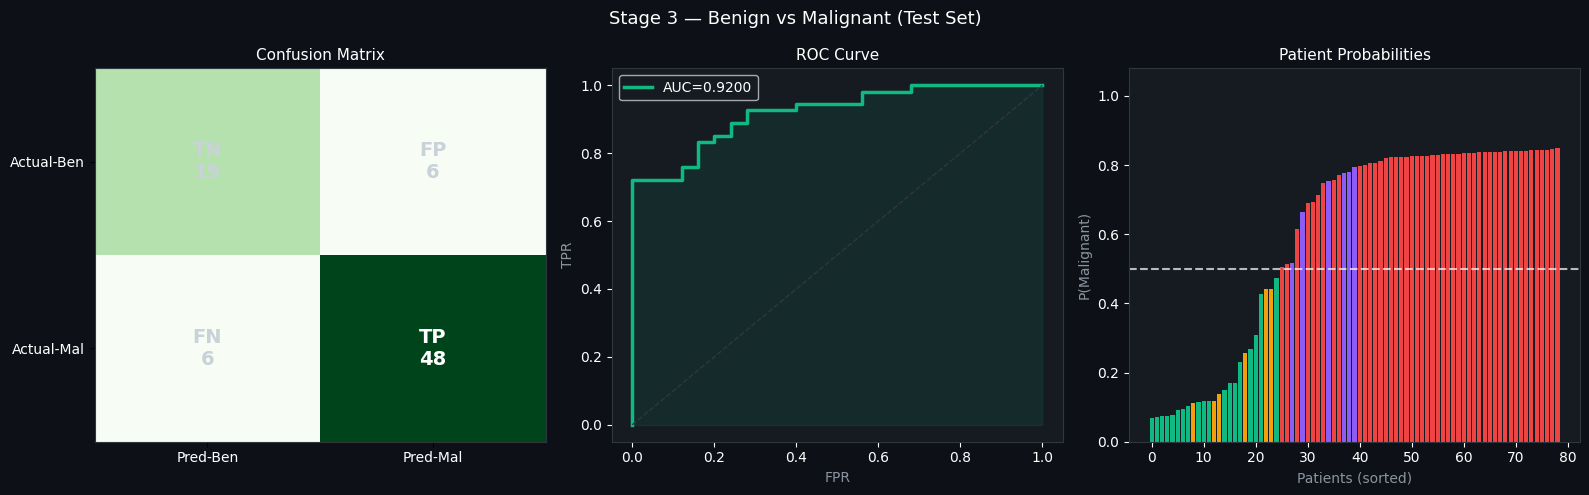

  AUC=0.9200  Acc=0.8481  F1=0.8889  Sens=0.8889  Spec=0.7600  PPV=0.8889
  TN=19 FP=6 FN=6 TP=48


In [18]:
if not STAGE3_OK:
    print("Stage 3 not loaded — skipping")
else:
    test_ds3 = Stage3Dataset(STAGE3_DATA, "test", augment=False, crop_size=CROP_SIZE)
    loader3  = DataLoader(test_ds3, batch_size=8, shuffle=False, num_workers=0)

    labels3_all, probs3_all, pids3_all = [], [], []
    offset = 0
    model_s3.eval()
    with torch.no_grad():
        for images, labels in loader3:
            images = images.to(device)
            with autocast(device_type=device.type, enabled=(device.type=="cuda")):
                logits = model_s3(images)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            for j in range(len(probs)):
                idx = offset+j
                pid = (os.path.basename(os.path.dirname(test_ds3.samples[idx][0]))
                       if idx < len(test_ds3.samples) else str(idx))
                pids3_all.append(pid)
            offset += len(probs)
            labels3_all.extend(labels.numpy().ravel().tolist())
            probs3_all.extend(probs.tolist())

    labels3_all = np.array(labels3_all); probs3_all = np.array(probs3_all)
    preds3_all  = (probs3_all >= THRESHOLD3).astype(int)

    if SKLEARN_OK and len(set(labels3_all)) > 1:
        auc3  = float(roc_auc_score(labels3_all, probs3_all))
        acc3  = float((preds3_all == labels3_all).mean())
        f1_3  = float(f1_score(labels3_all, preds3_all, zero_division=0))
        cm3   = confusion_matrix(labels3_all, preds3_all, labels=[0,1])
        tn3,fp3,fn3,tp3 = cm3.ravel()
        sens3 = float(tp3/(tp3+fn3)) if (tp3+fn3) else 0
        spec3 = float(tn3/(tn3+fp3)) if (tn3+fp3) else 0
        ppv3  = float(tp3/(tp3+fp3)) if (tp3+fp3) else 0

        fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
        fig.suptitle("Stage 3 — Benign vs Malignant (Test Set)", color="white", fontsize=13)

        ax = axes[0]; ax.set_facecolor(CARD)
        cm_v3 = np.array([[tn3,fp3],[fn3,tp3]])
        im3 = ax.imshow(cm_v3, cmap="Greens", aspect="auto")
        for i in range(2):
            for j in range(2):
                lbl_cm = [["TN","FP"],["FN","TP"]]
                ax.text(j,i,f"{lbl_cm[i][j]}\n{cm_v3[i,j]}", ha="center",va="center",
                        color="white" if cm_v3[i,j]>cm_v3.max()*0.5 else TEXT, fontsize=14, fontweight="bold")
        ax.set_xticks([0,1]); ax.set_xticklabels(["Pred-Ben","Pred-Mal"], color="white")
        ax.set_yticks([0,1]); ax.set_yticklabels(["Actual-Ben","Actual-Mal"], color="white")
        ax.set_title("Confusion Matrix", color="white", fontsize=11); ax.spines[:].set_color(BORDER)

        ax = axes[1]; ax.set_facecolor(CARD)
        fpr3,tpr3,_ = roc_curve(labels3_all, probs3_all)
        ax.plot(fpr3, tpr3, color=GREEN, lw=2.5, label=f"AUC={auc3:.4f}")
        ax.plot([0,1],[0,1], color=BORDER, lw=1, linestyle="--")
        ax.fill_between(fpr3, tpr3, alpha=0.1, color=GREEN)
        ax.set_xlabel("FPR", color=MUTED); ax.set_ylabel("TPR", color=MUTED)
        ax.set_title("ROC Curve", color="white", fontsize=11)
        ax.legend(facecolor=CARD, labelcolor="white")
        ax.tick_params(colors="white"); ax.spines[:].set_color(BORDER)

        ax = axes[2]; ax.set_facecolor(CARD)
        sidx3 = np.argsort(probs3_all)
        bar_col3 = []
        for p,l in zip(probs3_all[sidx3], labels3_all[sidx3]):
            pred = int(p>=THRESHOLD3)
            bar_col3.append((RED if l==1 else GREEN) if pred==l else (AMBER if l==1 else PURPLE))
        ax.bar(range(len(sidx3)), probs3_all[sidx3], color=bar_col3, width=0.8, edgecolor="none")
        ax.axhline(THRESHOLD3, color="white", lw=1.5, linestyle="--", alpha=0.7)
        ax.set_xlabel("Patients (sorted)", color=MUTED)
        ax.set_ylabel("P(Malignant)", color=MUTED)
        ax.set_title("Patient Probabilities", color="white", fontsize=11)
        ax.tick_params(colors="white"); ax.spines[:].set_color(BORDER)
        ax.set_ylim(0,1.08)

        plt.tight_layout()
        plt.savefig("stage3_eval.png", dpi=130, bbox_inches="tight", facecolor=BG)
        plt.show()
        print(f"  AUC={auc3:.4f}  Acc={acc3:.4f}  F1={f1_3:.4f}  Sens={sens3:.4f}  Spec={spec3:.4f}  PPV={ppv3:.4f}")
        print(f"  TN={tn3} FP={fp3} FN={fn3} TP={tp3}")


## 7. Training History — Both Stages

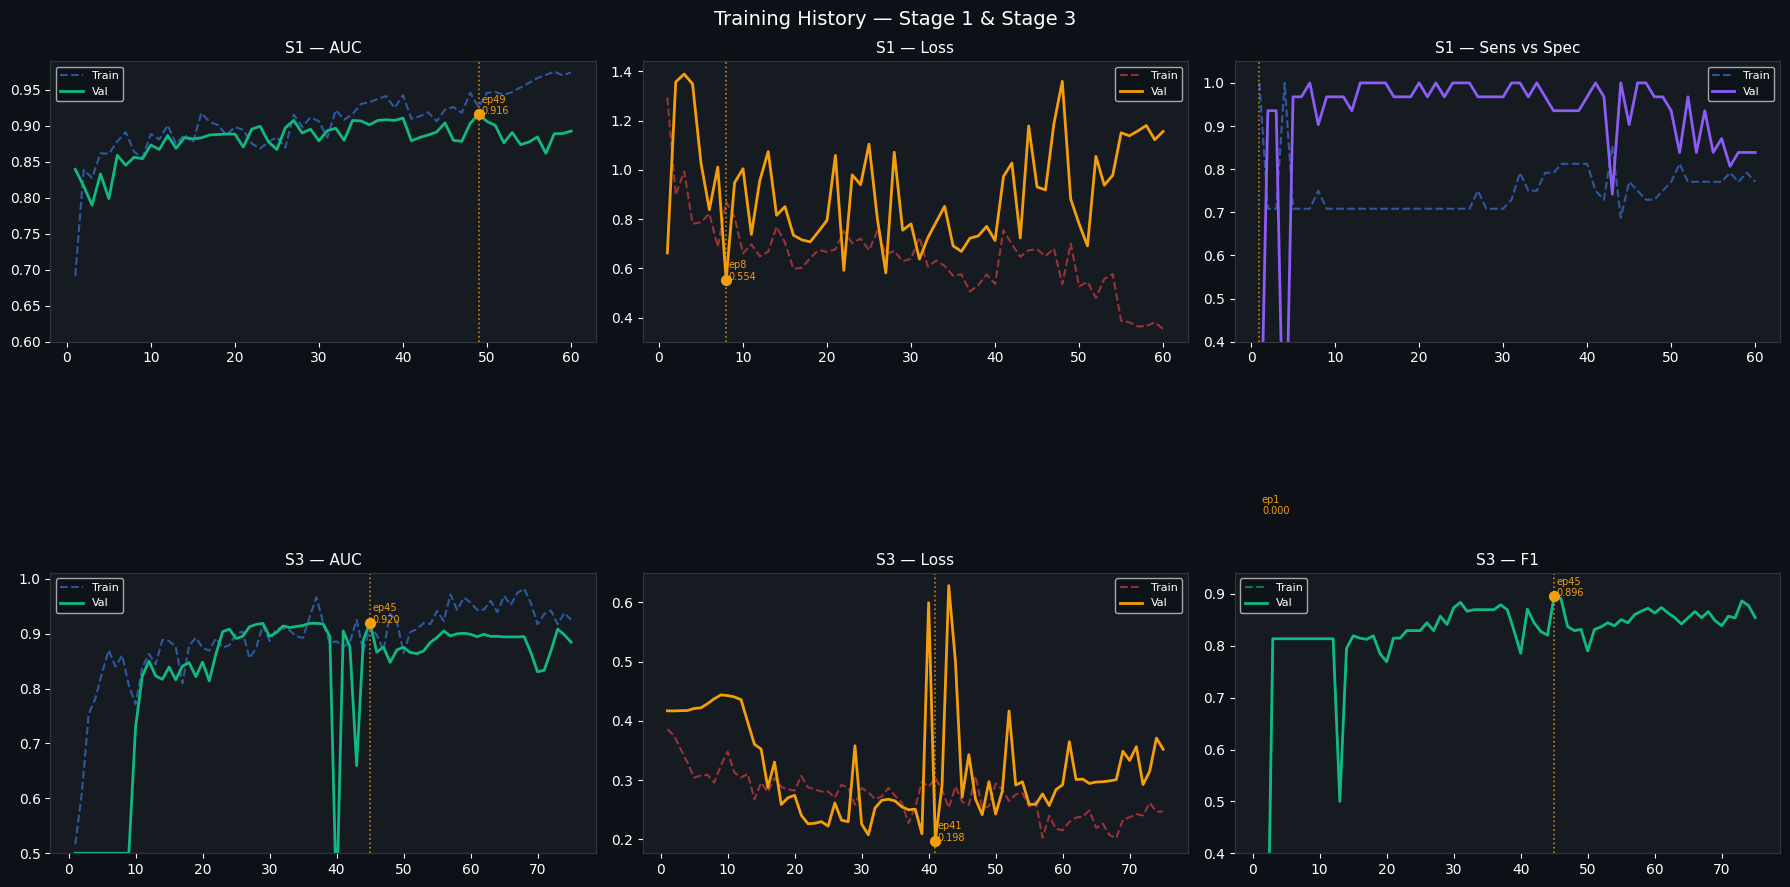

In [19]:
def _load_history(log_path):
    if not os.path.isfile(log_path): return {}
    with open(log_path) as f: log = json.load(f)
    h = {"val_auc":[],"train_auc":[],"val_loss":[],"train_loss":[],"val_f1":[],"val_sens":[],"val_spec":[]}
    for row in log.get("history",[]):
        for k in h:
            if k in row: h[k].append(row[k])
    return h

h1 = _load_history(STAGE1_LOG)
h3 = _load_history(STAGE3_LOG)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), facecolor=BG)
fig.suptitle("Training History — Stage 1 & Stage 3", color="white", fontsize=14)

def plot_curve(ax, h, key_t, key_v, title, col_t, col_v, ymin=None):
    ax.set_facecolor(CARD)
    t_v = h.get(key_t,[]); v_v = h.get(key_v,[])
    ep  = range(1, len(t_v)+1)
    if t_v: ax.plot(ep, t_v, color=col_t, lw=1.5, alpha=0.6, linestyle="--", label="Train")
    if v_v:
        ax.plot(range(1,len(v_v)+1), v_v, color=col_v, lw=2, label="Val")
        bi = int(np.argmax(v_v)) if "auc" in key_v or "f1" in key_v else int(np.argmin(v_v))
        ax.axvline(bi+1, color=AMBER, lw=1.2, linestyle=":", alpha=0.8)
        ax.scatter([bi+1],[v_v[bi]], color=AMBER, s=50, zorder=5)
        ax.text(bi+1.3, v_v[bi], f"ep{bi+1}\n{v_v[bi]:.3f}", color=AMBER, fontsize=7)
    ax.set_title(title, color="white", fontsize=11)
    ax.tick_params(colors="white"); ax.spines[:].set_color(BORDER)
    ax.legend(facecolor=BG, labelcolor="white", fontsize=8)
    if ymin: ax.set_ylim(bottom=ymin)

plot_curve(axes[0,0], h1, "train_auc", "val_auc",   "S1 — AUC",         BLUE,  GREEN, 0.6)
plot_curve(axes[0,1], h1, "train_loss","val_loss",   "S1 — Loss",        RED,   AMBER)
plot_curve(axes[0,2], h1, "val_sens",  "val_spec",   "S1 — Sens vs Spec",BLUE,  PURPLE, 0.4)
plot_curve(axes[1,0], h3, "train_auc", "val_auc",    "S3 — AUC",         BLUE,  GREEN, 0.5)
plot_curve(axes[1,1], h3, "train_loss","val_loss",   "S3 — Loss",        RED,   AMBER)
plot_curve(axes[1,2], h3, "val_f1",    "val_f1",     "S3 — F1",          GREEN, GREEN, 0.4)

plt.tight_layout()
plt.savefig("training_history.png", dpi=130, bbox_inches="tight", facecolor=BG)
plt.show()


## 8. Specific Patient Pipeline
Edit the `PATIENT_DIR` and labels below, then run. Works for any patient in any split.

Running full pipeline for patient: 102

  Patient : 102
  Stage 1 : prob=1.0  → Malignant
  Segment : 1300 voxels = 4387.5 mm³  |  Plateau — Type II
            T-stage: T2 (4–17 cm³)  |  Sphericity: 1.0
  Stage 3 : prob=0.8276  → Malignant



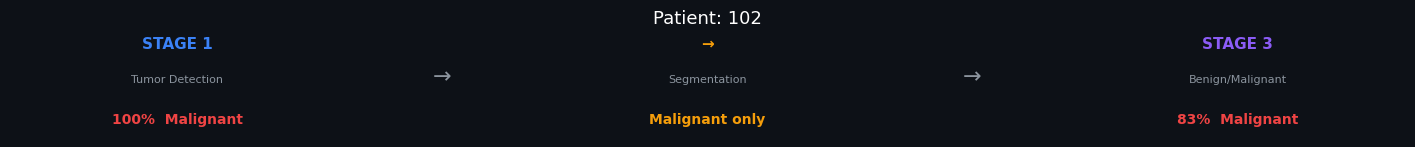

  ▶ Stage 1: Malignant (prob=1.0000)


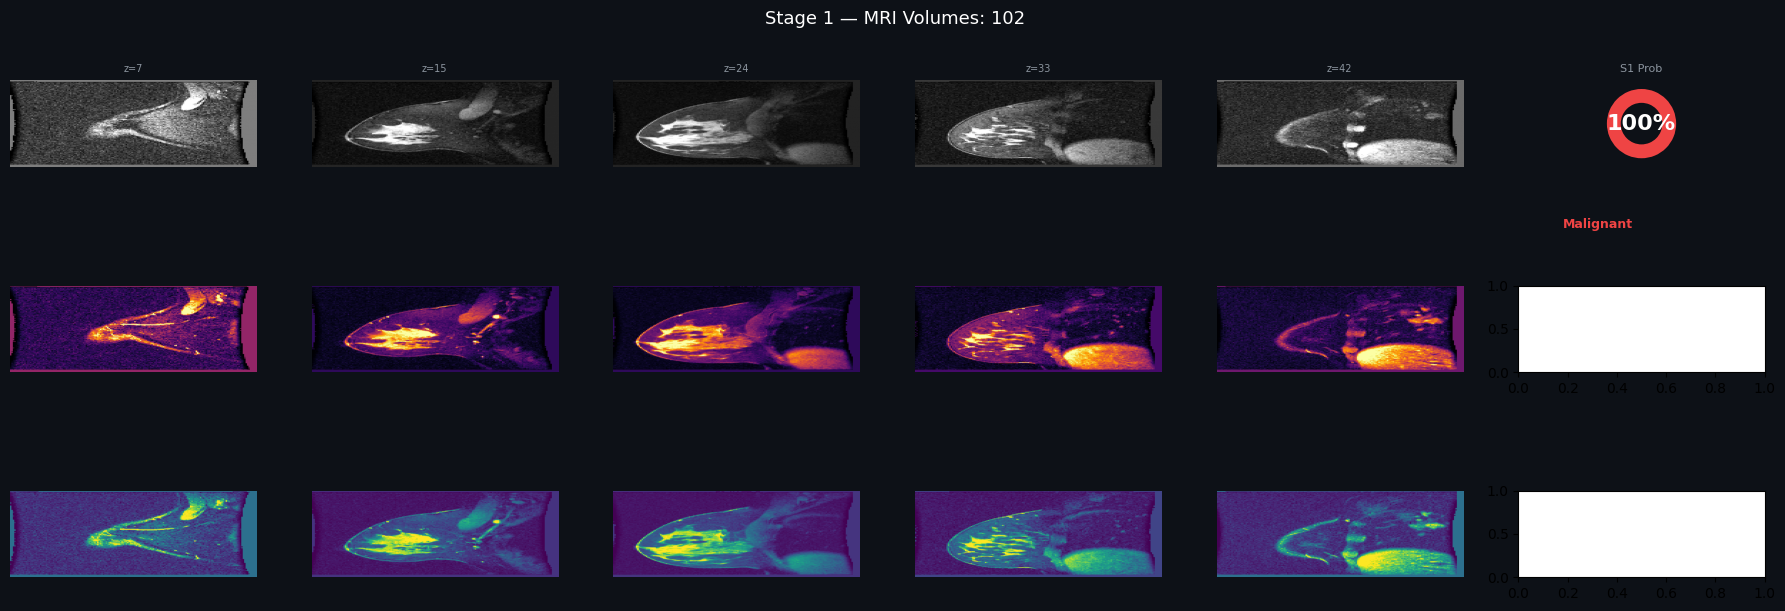

  ▶ Segmentation: 4388 mm³  |  Plateau — Type II  |  T2 (4–17 cm³)


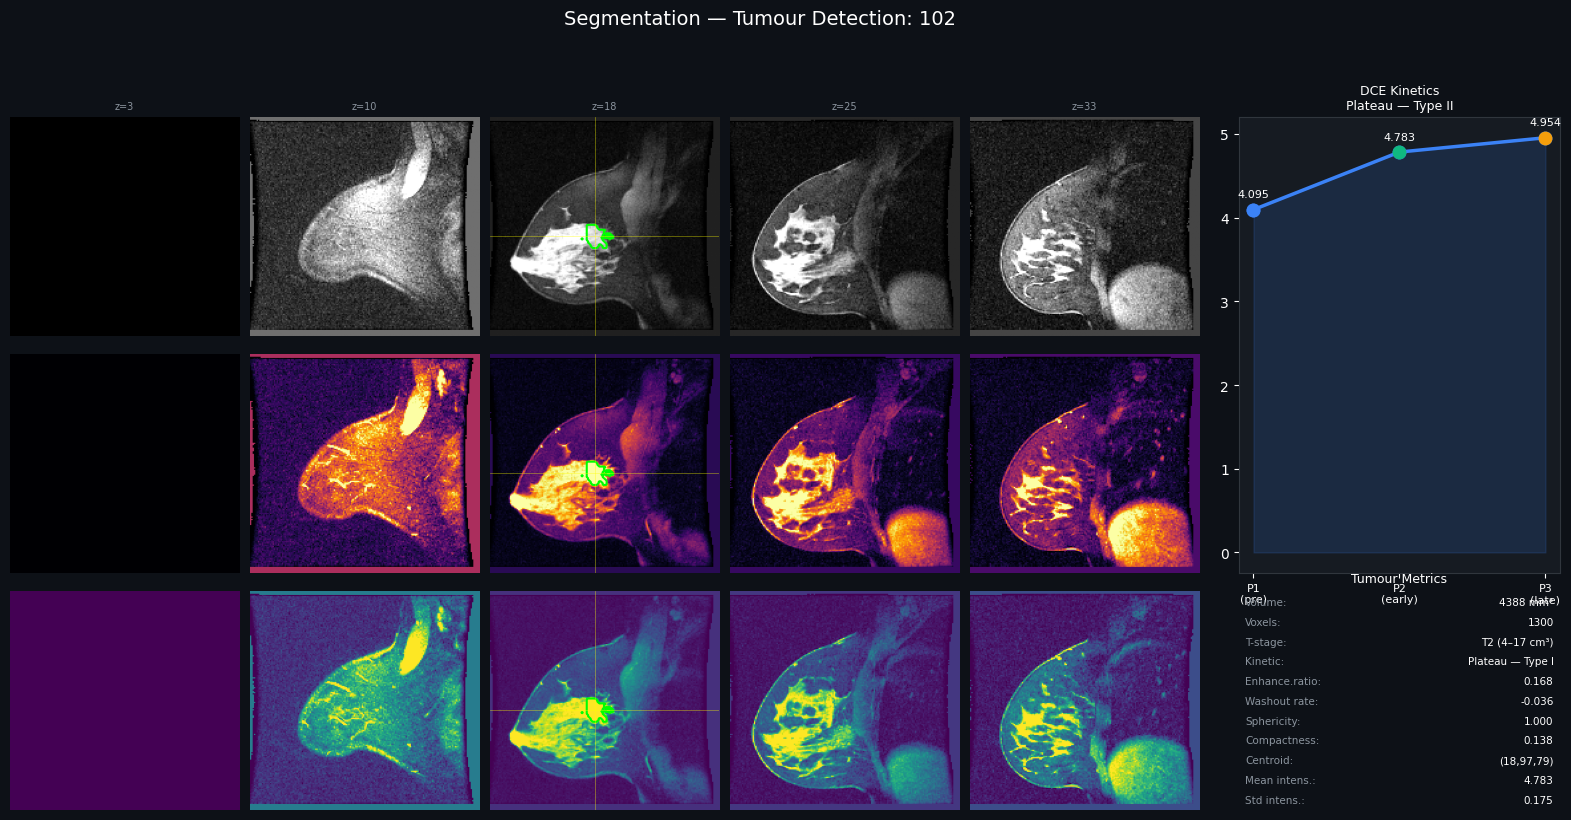

  ▶ Stage 3: Malignant (prob=0.8276)


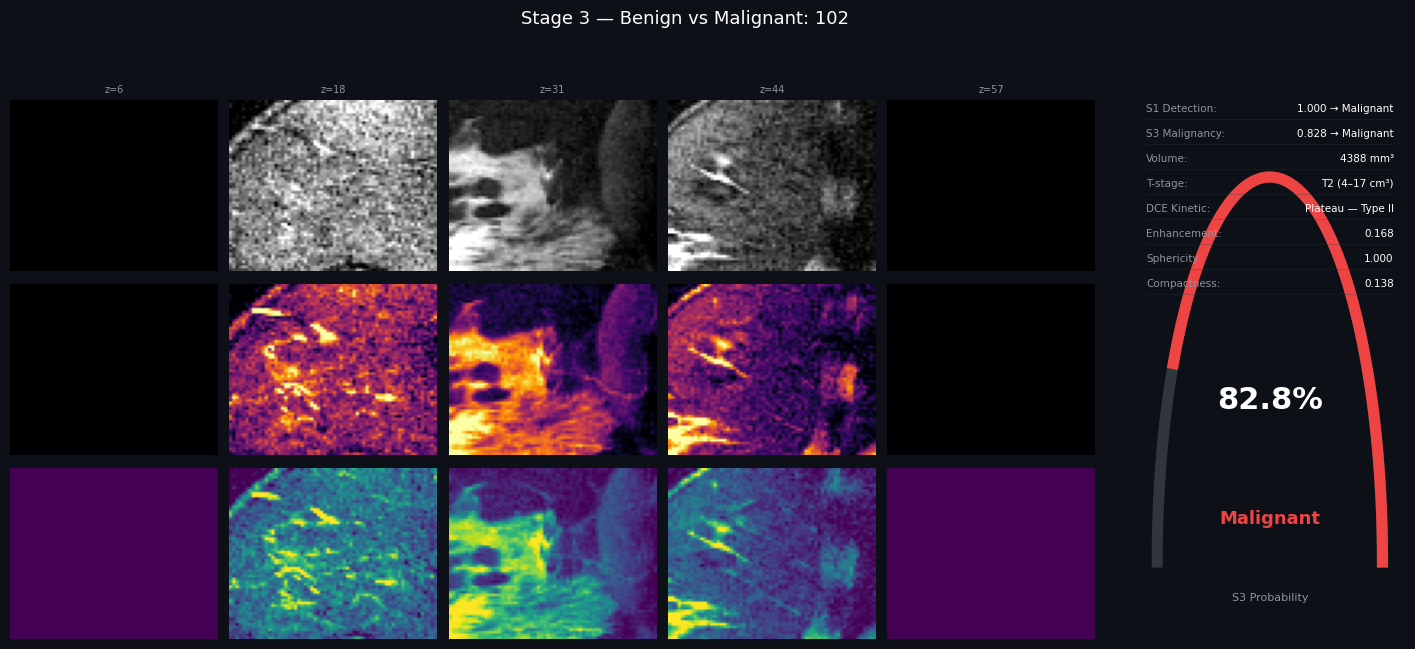

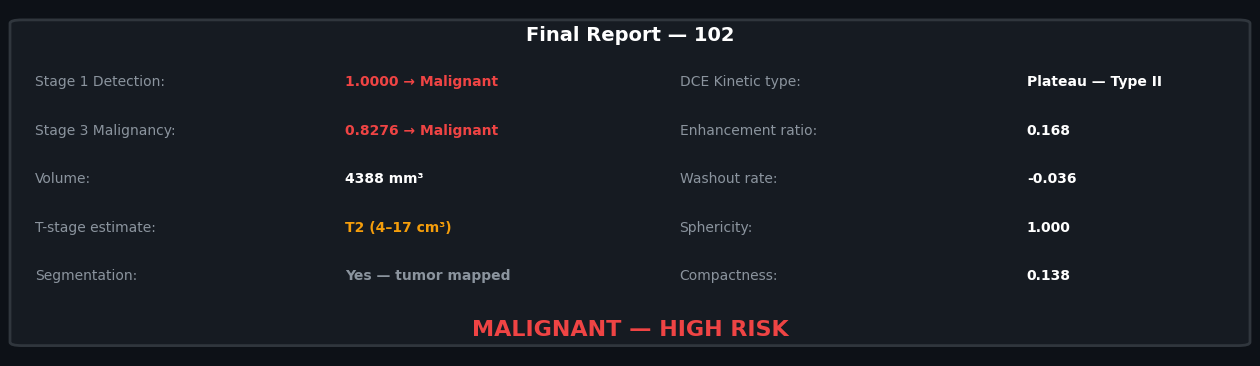

In [20]:
# ─── EDIT THESE ──────────────────────────────────────────────────────────────
PATIENT_DIR      = os.path.join(STAGE3_DATA, "test", "malignant")   # folder containing patient
PATIENT_ID       = None     # set to e.g. "67" to pick a specific patient, or None for first
TRUE_S1_LABEL    = 1        # 1=tumor present, 0=no tumor  (or None if unknown)
TRUE_S3_LABEL    = 1        # 1=malignant, 0=benign        (or None if unknown)
# ─────────────────────────────────────────────────────────────────────────────

if not os.path.isdir(PATIENT_DIR):
    print(f"Directory not found: {PATIENT_DIR}")
else:
    if PATIENT_ID is None:
        PATIENT_ID = sorted(os.listdir(PATIENT_DIR))[0]

    patient_path = os.path.join(PATIENT_DIR, PATIENT_ID)
    if not os.path.isdir(patient_path):
        print(f"Patient folder not found: {patient_path}")
    else:
        print(f"Running full pipeline for patient: {PATIENT_ID}\n")
        res_specific = run_pipeline(patient_path,
                                    true_s1=TRUE_S1_LABEL,
                                    true_s3=TRUE_S3_LABEL,
                                    verbose=True)
        print()
        vis_full_pipeline(res_specific)


## 9. Random Patient Pipeline
Picks a random patient from the test set and runs the complete pipeline.

Randomly selected patient: 120  (true class=MAL)

  Patient : 120
  Stage 1 : prob=1.0  → Malignant
  Segment : 9192 voxels = 31023.0 mm³  |  Plateau — Type II
            T-stage: T3+ (>17 cm³)  |  Sphericity: 1.0
  Stage 3 : prob=0.8359  → Malignant



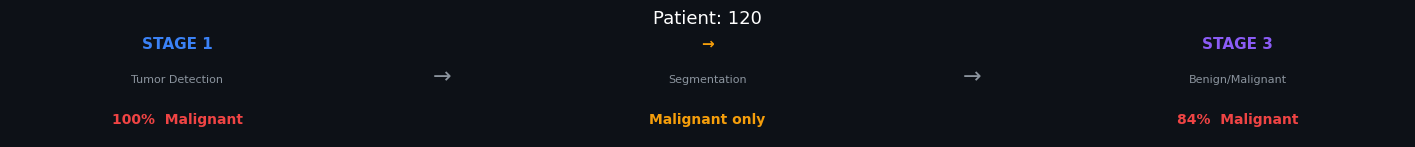

  ▶ Stage 1: Malignant (prob=1.0000)


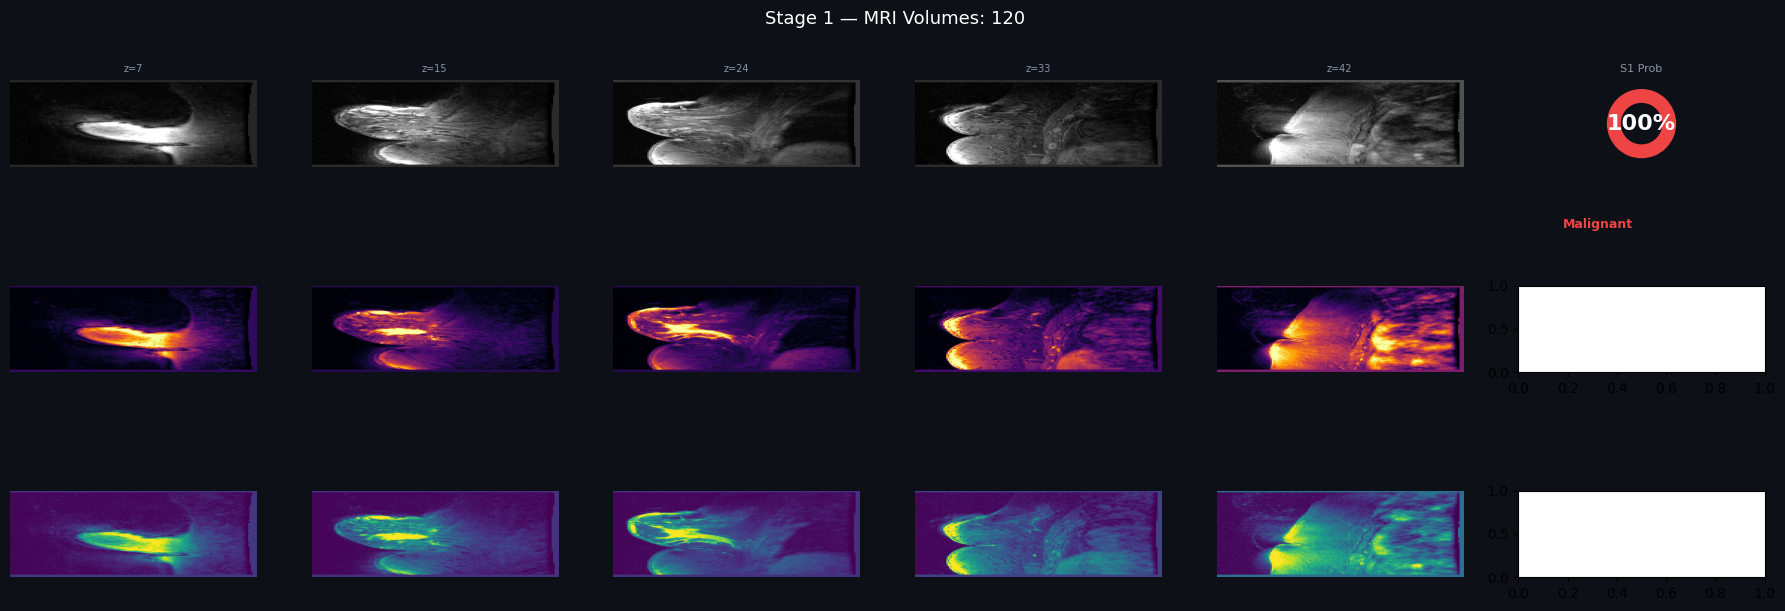

  ▶ Segmentation: 31023 mm³  |  Plateau — Type II  |  T3+ (>17 cm³)


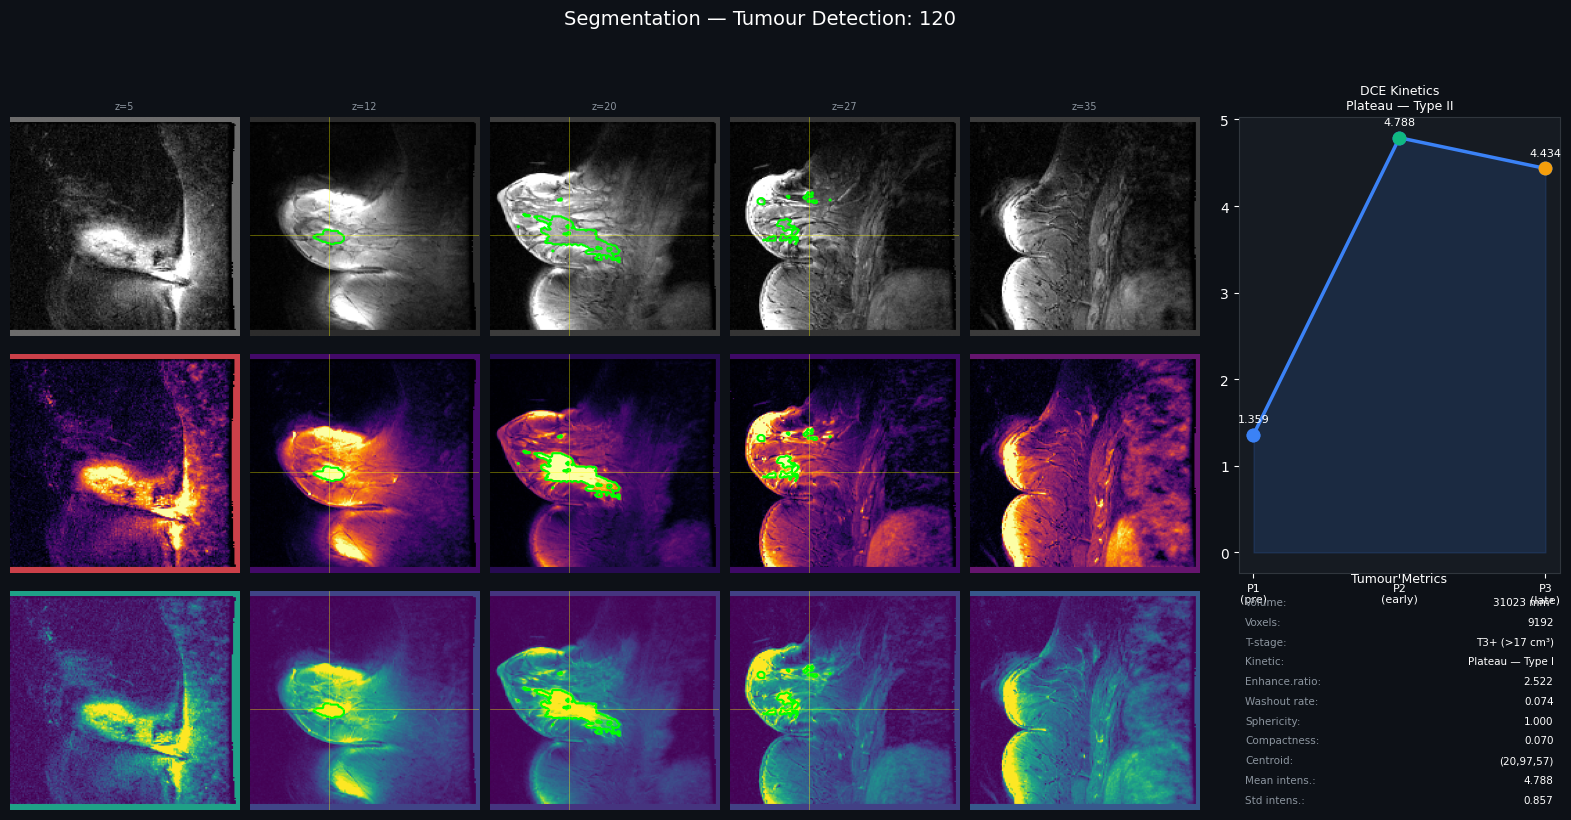

  ▶ Stage 3: Malignant (prob=0.8359)


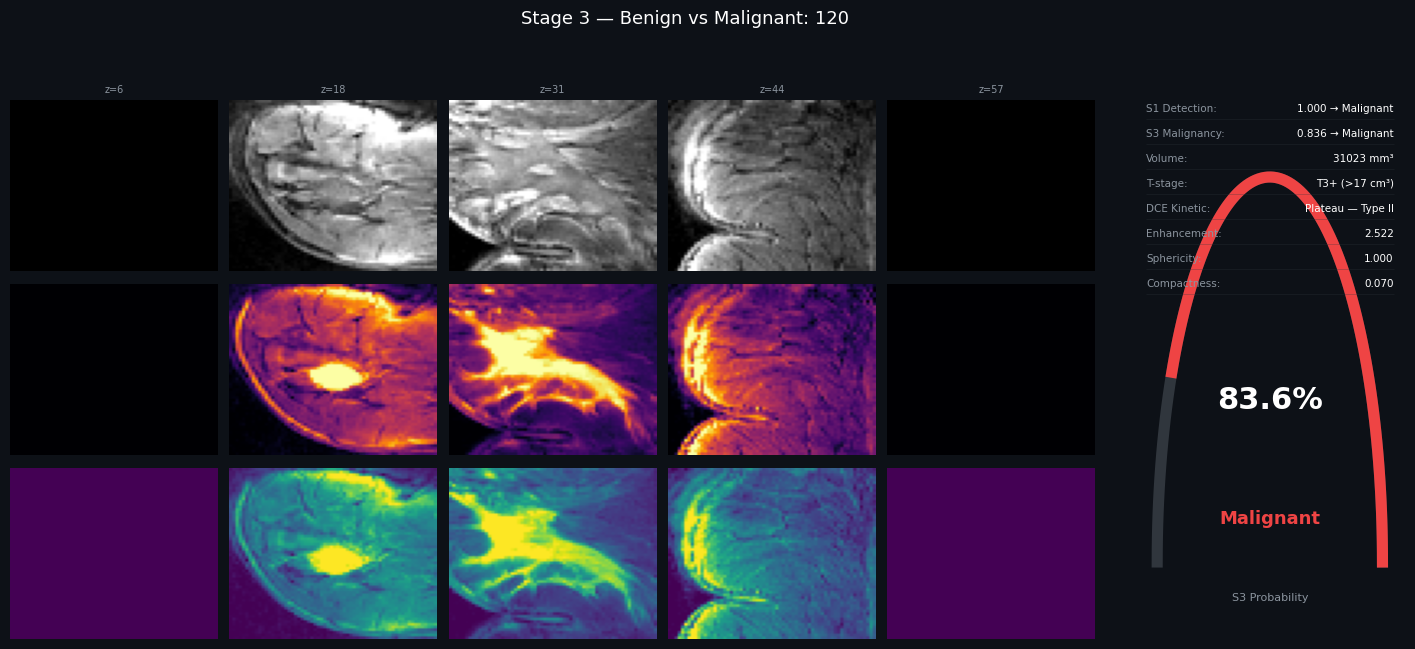

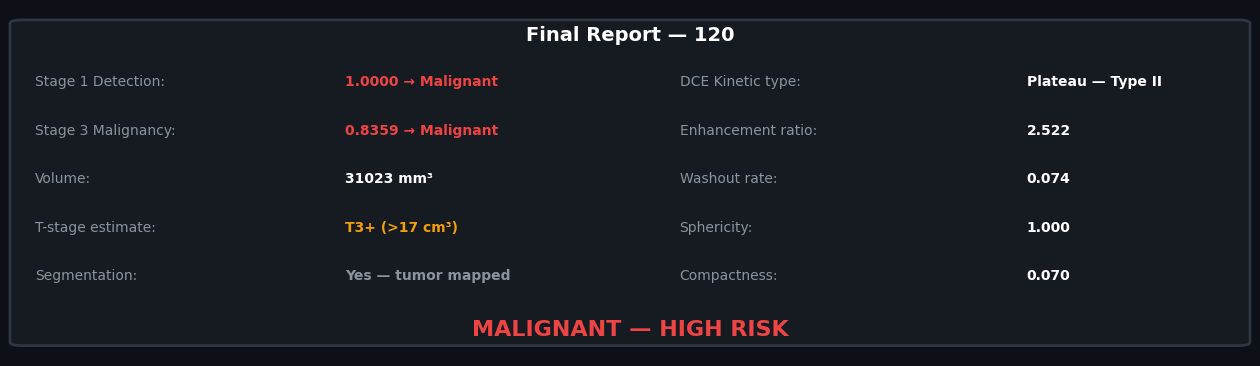

In [21]:
# ─── CONFIG ──────────────────────────────────────────────────────────────────
RANDOM_SEED   = None     # None for truly random each run, or an int for reproducibility
RANDOM_CLASS  = "any"   # "malignant", "benign", or "any"
# ─────────────────────────────────────────────────────────────────────────────

if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)

pool = []
for cls_name, lbl in [("malignant",1), ("benign",0)]:
    if RANDOM_CLASS not in ("any", cls_name): continue
    cls_dir = os.path.join(STAGE3_DATA, "test", cls_name)
    if os.path.isdir(cls_dir):
        for pid in os.listdir(cls_dir):
            if os.path.isfile(os.path.join(cls_dir, pid, "image.npy")):
                pool.append((os.path.join(cls_dir, pid), 1, lbl))

if not pool:
    print("No patients found. Check STAGE3_DATA path.")
else:
    rand_dir, rand_s1, rand_s3 = random.choice(pool)
    rand_pid = os.path.basename(rand_dir)
    print(f"Randomly selected patient: {rand_pid}  (true class={'MAL' if rand_s3 else 'BEN'})\n")
    res_random = run_pipeline(rand_dir, true_s1=rand_s1, true_s3=rand_s3, verbose=True)
    print()
    vis_full_pipeline(res_random)


## 10. Batch Pipeline — All Stage 3 Test Patients

In [22]:
all_results = []

for cls_name, true_s3 in [("malignant", 1), ("benign", 0)]:
    cls_dir = os.path.join(STAGE3_DATA, "test", cls_name)
    if not os.path.isdir(cls_dir): continue
    for pid in sorted(os.listdir(cls_dir)):
        pdir = os.path.join(cls_dir, pid)
        if not os.path.isfile(os.path.join(pdir, "image.npy")): continue
        res = run_pipeline(pdir, true_s1=1, true_s3=true_s3, verbose=False)
        if res: all_results.append(res)

print(f"Processed {len(all_results)} test patients")

s3_correct = sum(1 for r in all_results if r["s3_pred"] is not None and r["s3_pred"]==r["s3_true"])
fn_missed  = sum(1 for r in all_results if r["s3_true"]==1 and r["s3_pred"]==0)
fp_alarm   = sum(1 for r in all_results if r["s3_true"]==0 and r["s3_pred"]==1)
n_mal      = sum(1 for r in all_results if r["s3_true"]==1)
n_ben      = sum(1 for r in all_results if r["s3_true"]==0)

print(f"  Total          : {len(all_results)}")
print(f"  S3 correct     : {s3_correct}/{len(all_results)} = {s3_correct/max(len(all_results),1):.1%}")
print(f"  FN (missed)    : {fn_missed}/{n_mal}")
print(f"  FP (false alarm): {fp_alarm}/{n_ben}")

# Volume distribution
vols = [r["metrics"]["volume_mm3"] for r in all_results if r["metrics"]["voxels"] > 0]
kine = [r["metrics"]["kinetic_type"] for r in all_results if r["metrics"]["voxels"] > 0]
from collections import Counter
print(f"\n  Volume range: {min(vols):.0f} – {max(vols):.0f} mm³  (mean={np.mean(vols):.0f})")
print(f"  Kinetic types: {dict(Counter(kine))}")


Processed 79 test patients
  Total          : 79
  S3 correct     : 67/79 = 84.8%
  FN (missed)    : 6/54
  FP (false alarm): 6/25

  Volume range: 665 – 112198 mm³  (mean=16432)
  Kinetic types: {'Plateau — Type II': 33, 'Persistent — Type I': 2, 'Washout — Type III ★': 1}


## 11. Per-Patient Results Table

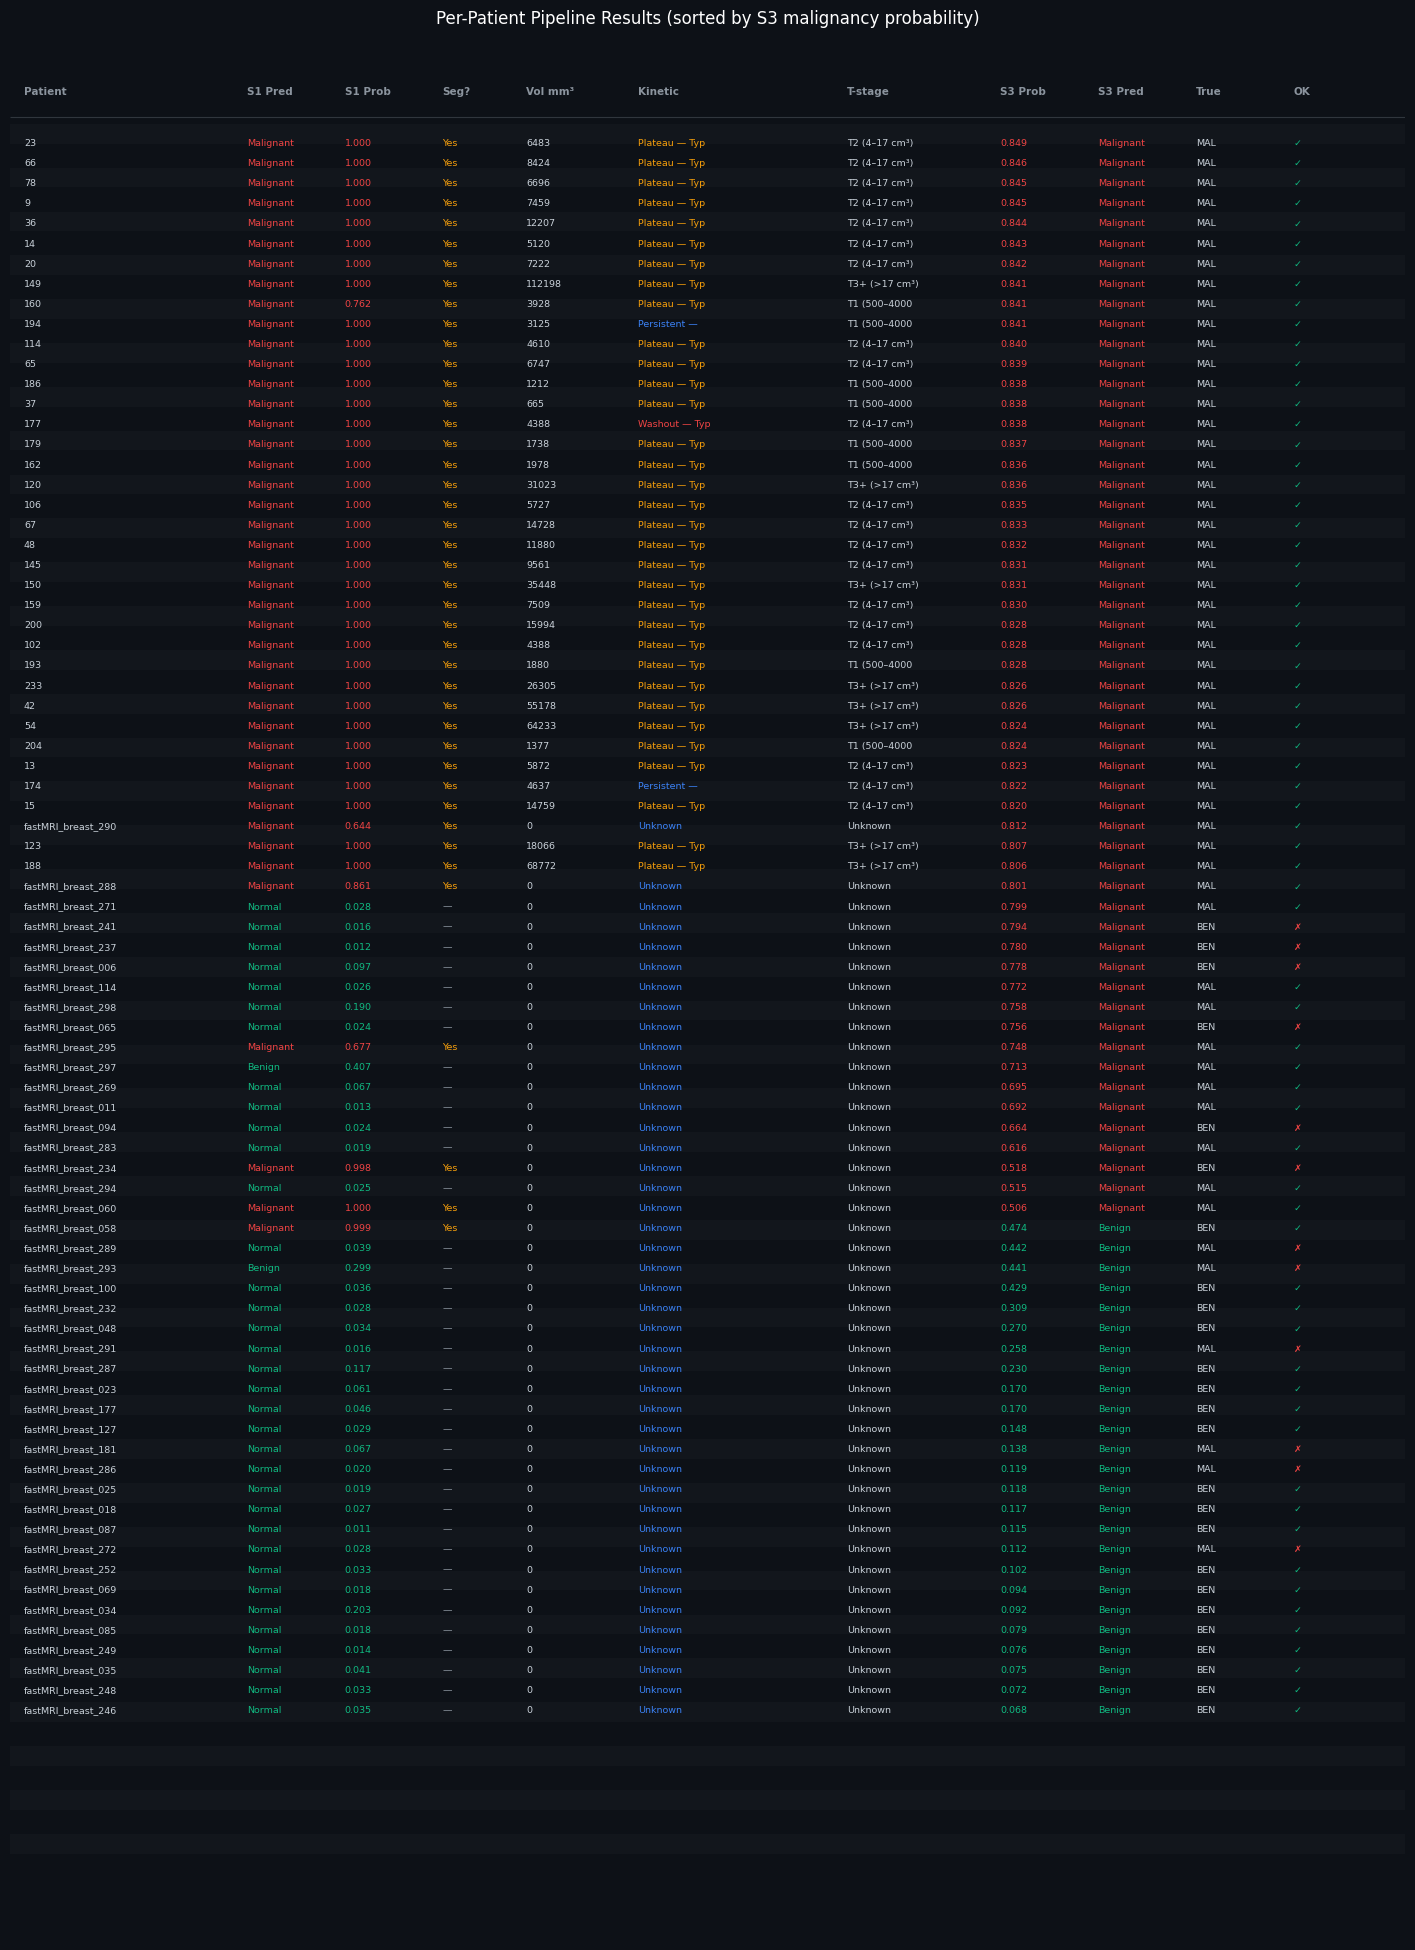

In [23]:
if not all_results:
    print("No results — run Cell 11 first")
else:
    sorted_r = sorted(all_results, key=lambda r: r["s3_prob"] or 0, reverse=True)

    fig, ax = plt.subplots(figsize=(18, max(5, len(sorted_r)*0.29 + 1.8)), facecolor=BG)
    ax.set_facecolor(BG); ax.axis("off")

    cols = ["Patient", "S1 Pred", "S1 Prob", "Seg?", "Vol mm³", "Kinetic", "T-stage", "S3 Prob", "S3 Pred", "True", "OK"]
    col_x = [0.01, 0.17, 0.24, 0.31, 0.37, 0.45, 0.60, 0.71, 0.78, 0.85, 0.92]
    n     = len(sorted_r)
    rh    = 0.85 / (n + 1.5)

    for c, cx in zip(cols, col_x):
        ax.text(cx, 0.97, c, transform=ax.transAxes, color=MUTED, fontsize=7.5, fontweight="bold")
    ax.hlines(0.958, xmin=0, xmax=1, color=BORDER, lw=0.8, transform=ax.transAxes)

    for i, r in enumerate(sorted_r):
        y      = 0.955 - (i+1)*rh
        s1_str = r["s1_label"]
        s3p    = r["s3_prob"] or 0
        s3_str = r["s3_label"]
        t_str  = "MAL" if r["s3_true"]==1 else "BEN"
        ok     = (r["s3_pred"]==r["s3_true"])
        ok_str = "✓" if ok else "✗"
        m      = r["metrics"]
        seg_str= "Yes" if r["seg_ran"] else "—"

        s1_col = RED if r["s1_pred"]==1 else GREEN
        s3_col = RED if s3p>=THRESHOLD3 else GREEN
        ok_col = GREEN if ok else RED
        kin_col= RED if "III" in m["kinetic_type"] else (AMBER if "II" in m["kinetic_type"] else BLUE)

        vals   = [r["pid"][:18], s1_str, f"{r['s1_prob']:.3f}", seg_str,
                  f"{m['volume_mm3']:.0f}", m["kinetic_type"][:13],
                  m["t_stage"][:13], f"{s3p:.3f}", s3_str, t_str, ok_str]
        colors = [TEXT, s1_col, s1_col, AMBER if r["seg_ran"] else MUTED,
                  TEXT, kin_col, TEXT, s3_col, s3_col, TEXT, ok_col]

        for v, cx, vc in zip(vals, col_x, colors):
            ax.text(cx, y, v, transform=ax.transAxes, color=vc, fontsize=6.8, va="center")
        if i % 2 == 0:
            ax.axhspan(y-rh*0.4, y+rh*0.5, xmin=0, xmax=1,
                       facecolor="#ffffff06", transform=ax.transAxes)

    ax.set_title("Per-Patient Pipeline Results (sorted by S3 malignancy probability)",
                 color="white", fontsize=12, pad=10)
    plt.savefig("patient_results_table.png", dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()


## 12. Tumour Distribution Analysis

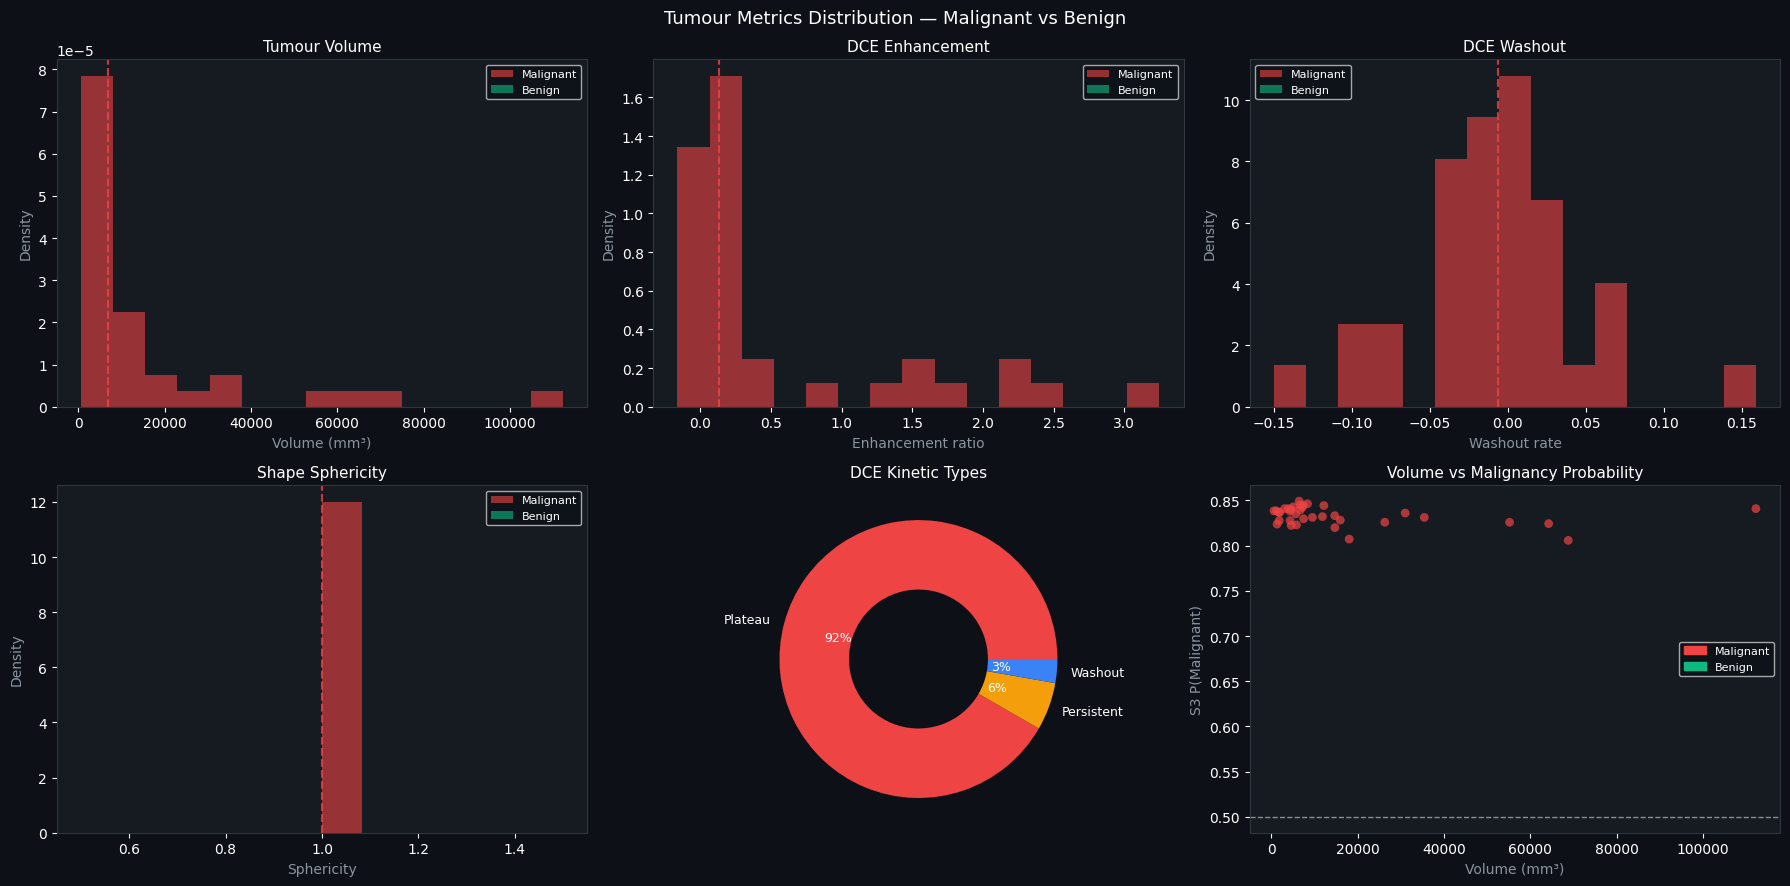

In [24]:
if not all_results:
    print("No results — run Cell 11 first")
else:
    mal_r = [r for r in all_results if r["s3_true"]==1 and r["metrics"]["voxels"]>0]
    ben_r = [r for r in all_results if r["s3_true"]==0 and r["metrics"]["voxels"]>0]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9), facecolor=BG)
    fig.suptitle("Tumour Metrics Distribution — Malignant vs Benign", color="white", fontsize=13)

    def hist_compare(ax, mal_vals, ben_vals, xlabel, title, bins=15):
        ax.set_facecolor(CARD)
        ax.hist(mal_vals, bins=bins, color=RED,   alpha=0.6, label="Malignant", density=True)
        ax.hist(ben_vals, bins=bins, color=GREEN, alpha=0.6, label="Benign",    density=True)
        ax.axvline(np.median(mal_vals), color=RED,   lw=1.5, linestyle="--", alpha=0.8)
        ax.axvline(np.median(ben_vals), color=GREEN, lw=1.5, linestyle="--", alpha=0.8)
        ax.set_xlabel(xlabel, color=MUTED); ax.set_ylabel("Density", color=MUTED)
        ax.set_title(title, color="white", fontsize=11)
        ax.tick_params(colors="white"); ax.spines[:].set_color(BORDER)
        ax.legend(facecolor=BG, labelcolor="white", fontsize=8)

    vols_m = [r["metrics"]["volume_mm3"] for r in mal_r]
    vols_b = [r["metrics"]["volume_mm3"] for r in ben_r]
    hist_compare(axes[0,0], vols_m, vols_b, "Volume (mm³)", "Tumour Volume")

    er_m = [r["metrics"]["enhancement_ratio"] for r in mal_r]
    er_b = [r["metrics"]["enhancement_ratio"] for r in ben_r]
    hist_compare(axes[0,1], er_m, er_b, "Enhancement ratio", "DCE Enhancement")

    wr_m = [r["metrics"]["washout_rate"] for r in mal_r]
    wr_b = [r["metrics"]["washout_rate"] for r in ben_r]
    hist_compare(axes[0,2], wr_m, wr_b, "Washout rate", "DCE Washout")

    sp_m = [r["metrics"]["sphericity"] for r in mal_r]
    sp_b = [r["metrics"]["sphericity"] for r in ben_r]
    hist_compare(axes[1,0], sp_m, sp_b, "Sphericity", "Shape Sphericity", bins=12)

    # Kinetic type donut
    from collections import Counter
    ax = axes[1,1]; ax.set_facecolor(CARD)
    kine_counts = Counter(r["metrics"]["kinetic_type"].split(" ")[0] for r in all_results if r["metrics"]["voxels"]>0)
    kcolors = [RED, AMBER, BLUE]
    ax.pie(list(kine_counts.values()), labels=list(kine_counts.keys()),
           colors=kcolors[:len(kine_counts)], autopct="%1.0f%%",
           textprops={"color":"white","fontsize":9},
           wedgeprops={"width":0.5})
    ax.set_title("DCE Kinetic Types", color="white", fontsize=11)

    # S3 prob scatter vs volume
    ax = axes[1,2]; ax.set_facecolor(CARD)
    for r in all_results:
        if r["metrics"]["voxels"] > 0 and r["s3_prob"] is not None:
            c = RED if r["s3_true"]==1 else GREEN
            ax.scatter(r["metrics"]["volume_mm3"], r["s3_prob"],
                       color=c, alpha=0.7, s=40, edgecolors="none")
    ax.axhline(THRESHOLD3, color="white", lw=1, linestyle="--", alpha=0.5)
    ax.set_xlabel("Volume (mm³)", color=MUTED)
    ax.set_ylabel("S3 P(Malignant)", color=MUTED)
    ax.set_title("Volume vs Malignancy Probability", color="white", fontsize=11)
    ax.tick_params(colors="white"); ax.spines[:].set_color(BORDER)
    legend_el = [mpatches.Patch(color=RED, label="Malignant"), mpatches.Patch(color=GREEN, label="Benign")]
    ax.legend(handles=legend_el, facecolor=BG, labelcolor="white", fontsize=8)

    plt.tight_layout()
    plt.savefig("tumor_distribution.png", dpi=130, bbox_inches="tight", facecolor=BG)
    plt.show()


## 13. Project Summary Card

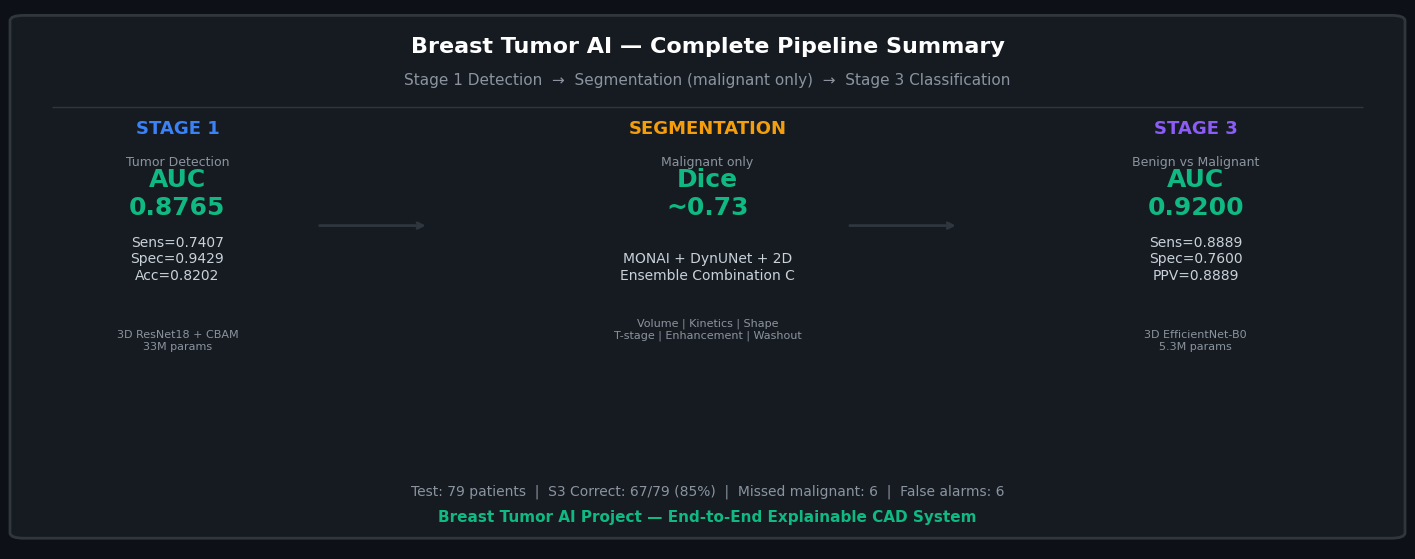

In [25]:
fig, ax = plt.subplots(figsize=(18, 7), facecolor=BG)
ax.set_facecolor(BG); ax.axis("off")

card = mpatches.FancyBboxPatch((0.01,0.03), 0.98, 0.95,
                                boxstyle="round,pad=0.01",
                                transform=ax.transAxes,
                                facecolor=CARD, edgecolor=BORDER, lw=2, clip_on=False)
ax.add_patch(card)

ax.text(0.5, 0.92, "Breast Tumor AI — Complete Pipeline Summary",
        ha="center", color="white", fontsize=16, fontweight="bold", transform=ax.transAxes)
ax.text(0.5, 0.86, "Stage 1 Detection  →  Segmentation (malignant only)  →  Stage 3 Classification",
        ha="center", color=MUTED, fontsize=11, transform=ax.transAxes)
ax.hlines(0.82, 0.03, 0.97, color=BORDER, lw=1, transform=ax.transAxes)

# Stage 1 column
try: auc1_str = f"{auc1:.4f}"
except: auc1_str = "—"
try: sens1_str = f"{sens1:.4f}"; spec1_str = f"{spec1:.4f}"; acc1_str = f"{acc1:.4f}"
except: sens1_str=spec1_str=acc1_str="—"

ax.text(0.12, 0.77, "STAGE 1",          ha="center", color=BLUE,  fontsize=13, fontweight="bold", transform=ax.transAxes)
ax.text(0.12, 0.71, "Tumor Detection",  ha="center", color=MUTED, fontsize=9,  transform=ax.transAxes)
ax.text(0.12, 0.62, f"AUC\n{auc1_str}", ha="center", color=GREEN, fontsize=18, fontweight="bold", transform=ax.transAxes)
ax.text(0.12, 0.50, f"Sens={sens1_str}\nSpec={spec1_str}\nAcc={acc1_str}", ha="center", color=TEXT, fontsize=10, transform=ax.transAxes)
ax.text(0.12, 0.37, "3D ResNet18 + CBAM\n33M params", ha="center", color=MUTED, fontsize=8, transform=ax.transAxes)

ax.annotate("", xy=(0.30,0.60), xytext=(0.22,0.60), xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color=BORDER, lw=2))

# Segmentation column
ax.text(0.50, 0.77, "SEGMENTATION",         ha="center", color=AMBER, fontsize=13, fontweight="bold", transform=ax.transAxes)
ax.text(0.50, 0.71, "Malignant only",        ha="center", color=MUTED, fontsize=9,  transform=ax.transAxes)
ax.text(0.50, 0.62, "Dice\n~0.73",          ha="center", color=GREEN, fontsize=18, fontweight="bold", transform=ax.transAxes)
ax.text(0.50, 0.50, "MONAI + DynUNet + 2D\nEnsemble Combination C", ha="center", color=TEXT, fontsize=10, transform=ax.transAxes)
ax.text(0.50, 0.39, "Volume | Kinetics | Shape\nT-stage | Enhancement | Washout",
        ha="center", color=MUTED, fontsize=8, transform=ax.transAxes)

ax.annotate("", xy=(0.68,0.60), xytext=(0.60,0.60), xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="->", color=BORDER, lw=2))

# Stage 3 column
try: auc3_str = f"{auc3:.4f}"
except: auc3_str = "—"
try: sens3_str=f"{sens3:.4f}"; spec3_str=f"{spec3:.4f}"; ppv3_str=f"{ppv3:.4f}"
except: sens3_str=spec3_str=ppv3_str="—"

ax.text(0.85, 0.77, "STAGE 3",              ha="center", color=PURPLE, fontsize=13, fontweight="bold", transform=ax.transAxes)
ax.text(0.85, 0.71, "Benign vs Malignant",  ha="center", color=MUTED,  fontsize=9,  transform=ax.transAxes)
ax.text(0.85, 0.62, f"AUC\n{auc3_str}",   ha="center", color=GREEN,  fontsize=18, fontweight="bold", transform=ax.transAxes)
ax.text(0.85, 0.50, f"Sens={sens3_str}\nSpec={spec3_str}\nPPV={ppv3_str}", ha="center", color=TEXT, fontsize=10, transform=ax.transAxes)
ax.text(0.85, 0.37, "3D EfficientNet-B0\n5.3M params", ha="center", color=MUTED, fontsize=8, transform=ax.transAxes)

# Bottom status
if all_results:
    bottom = (f"Test: {len(all_results)} patients  |  "
              f"S3 Correct: {s3_correct}/{len(all_results)} ({s3_correct/len(all_results):.0%})  |  "
              f"Missed malignant: {fn_missed}  |  False alarms: {fp_alarm}")
    ax.text(0.5, 0.10, bottom, ha="center", color=MUTED, fontsize=10, transform=ax.transAxes)

ax.text(0.5, 0.05, "Breast Tumor AI Project — End-to-End Explainable CAD System",
        ha="center", color=GREEN, fontsize=11, fontweight="bold", transform=ax.transAxes)

plt.savefig("pipeline_summary_card.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
